# SWOT Satellite Data Analysis
## Kakhovka & Lower Dnipro, Ukraine — Shapefile Pipeline

**Products:** `SWOT_L2_HR_LakeSP_2.0` · `SWOT_L2_HR_RiverSP_2.0`
**Format:** `.zip` archives → Shapefiles (`.shp`)
**Key event:** Kakhovka Dam breach **June 6, 2023**

## 1. Setup & Imports

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')

from pathlib import Path
from collections import Counter
import re, json

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from IPython.display import display

try:
    import folium
    from folium import GeoJson, Marker, CircleMarker, LayerControl
    HAS_FOLIUM = True
except ImportError:
    HAS_FOLIUM = False

try:
    import xlrd
    HAS_XLRD = True
except ImportError:
    HAS_XLRD = False
    print("[WARN] xlrd not found — gauge parsing disabled. Run: pip install xlrd")

sns.set_theme(style='whitegrid', font_scale=1.05)
print("Imports OK")

Imports OK


## 2. Configuration

In [2]:
ROOT        = Path('..').resolve()
DATA_DIR    = ROOT / 'data'
RAW_DIR     = DATA_DIR / 'raw'
LAKESP_DIR  = RAW_DIR / 'swot_l2_hr_lakesp_2.0'
RIVERSP_DIR = RAW_DIR / 'swot_l2_hr_riversp_2.0'
FIG_DIR     = DATA_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

KAKHOVKA_SA   = DATA_DIR / 'Kakhovka_SA.geojson'
# Hydrological yearbook 2023 — gauge station 80805 р.Дніпро - м.Херсон
GAUGE_XLS     = DATA_DIR / '\u0413\u0406\u0414\u0420\u041e\u041b\u041e\u0413\u0406\u042f_2023' /                 '\u0413\u0406\u0414\u0420\u041e\u041b\u041e\u0413\u0406\u042f_2023' /                 'v 2' / 'Tabl 1-2' / 'Tabl 1-2' / '80805U_2023.xls'

DAM_BREACH = pd.Timestamp('2023-06-06')
BREACH_END  = pd.Timestamp('2023-07-01')

# WSE filter: removes fill values and non-reservoir water bodies
WSE_MIN, WSE_MAX = 0.0, 50.0
# Kakhovka reservoir WSE: ~7-15 m pre-breach, < 3 m post-breach (EGM08 geoid)
KAKH_WSE_LO, KAKH_WSE_HI = 1.0, 20.0

COORDS = {
    'Kakhovka Dam':      (47.3589, 33.3748),
    'Kherson':           (46.6566, 32.6819),
    'Black Sea mouth':   (46.5309, 32.2636),
    'Dniprovske centre': (47.8819, 35.0979),
}

# Kherson gauge station 80805 (datum: -5.00 m BS-77, lat≈46.636, lon≈32.619)
GAUGE_STATION = {'name': 'р.Дніпро - м.Херсон (80805)', 'lat': 46.636, 'lon': 32.619}

print("Directories:")
for name, path in [('LAKESP_DIR', LAKESP_DIR), ('RIVERSP_DIR', RIVERSP_DIR)]:
    print(f"  {name}: {path}  [{'exists' if path.exists() else 'MISSING'}]")
print(f"  GAUGE_XLS: {GAUGE_XLS}  [{'exists' if GAUGE_XLS.exists() else 'MISSING'}]")

Directories:
  LAKESP_DIR: /mnt/c/Users/victo/PycharmProjects/SWOT-DNIPRO/data/raw/swot_l2_hr_lakesp_2.0  [exists]
  RIVERSP_DIR: /mnt/c/Users/victo/PycharmProjects/SWOT-DNIPRO/data/raw/swot_l2_hr_riversp_2.0  [exists]
  GAUGE_XLS: /mnt/c/Users/victo/PycharmProjects/SWOT-DNIPRO/data/ГІДРОЛОГІЯ_2023/ГІДРОЛОГІЯ_2023/v 2/Tabl 1-2/Tabl 1-2/80805U_2023.xls  [exists]


## 3. Explore Downloaded Shapefiles

LakeSP  shapefiles : 1,685
RiverSP shapefiles : 1,891


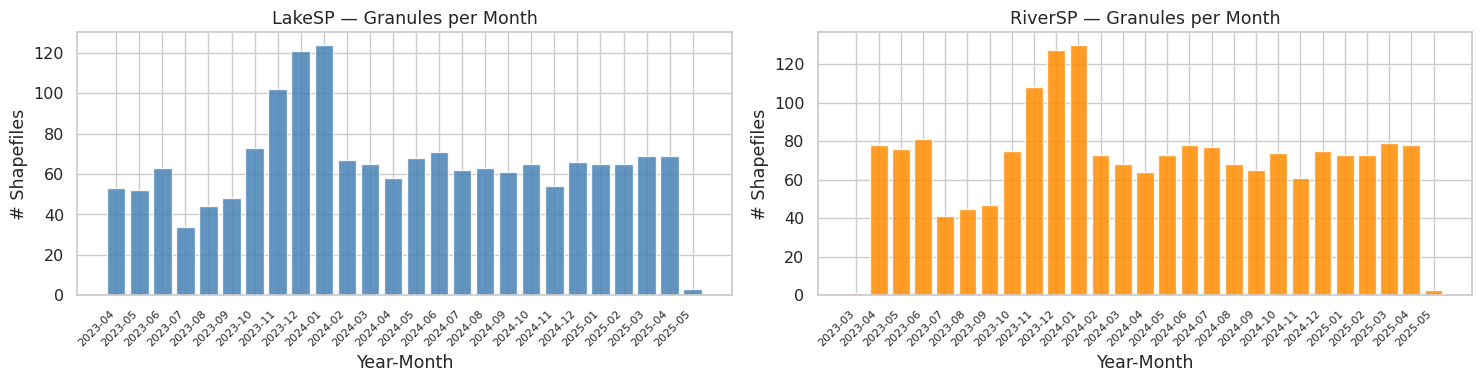

Saved: /mnt/c/Users/victo/PycharmProjects/SWOT-DNIPRO/data/figures/00_granule_coverage.png


In [3]:
lakesp_shps  = sorted(LAKESP_DIR.rglob('*.shp'))  if LAKESP_DIR.exists()  else []
riversp_shps = sorted(RIVERSP_DIR.rglob('*.shp')) if RIVERSP_DIR.exists() else []

print(f"LakeSP  shapefiles : {len(lakesp_shps):,}")
print(f"RiverSP shapefiles : {len(riversp_shps):,}")

def month_counts(shp_list):
    cnt = Counter()
    for p in shp_list:
        parts = p.parts
        try:
            mm_idx = -2
            cnt[f"{parts[mm_idx-1]}-{parts[mm_idx]}"] += 1
        except IndexError:
            cnt['unknown'] += 1
    return dict(sorted(cnt.items()))

mc_lake  = month_counts(lakesp_shps)
mc_river = month_counts(riversp_shps)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, mc, title, color in [
    (axes[0], mc_lake,  'LakeSP',  'steelblue'),
    (axes[1], mc_river, 'RiverSP', 'darkorange'),
]:
    ax.bar(list(mc.keys()), list(mc.values()), color=color, alpha=0.85)
    ax.set_title(f'{title} — Granules per Month')
    ax.set_xlabel('Year-Month'); ax.set_ylabel('# Shapefiles')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / '00_granule_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIG_DIR / '00_granule_coverage.png'}")

## 4. Inspect One Shapefile (LakeSP + RiverSP)

In [4]:
if lakesp_shps:
    gdf_sample = gpd.read_file(lakesp_shps[0])
    print(f"LakeSP — {lakesp_shps[0].name}")
    print(f"  Rows: {len(gdf_sample):,}  |  CRS: {gdf_sample.crs}")
    print(f"  Geometry: {gdf_sample.geometry.type.value_counts().to_dict()}")
    print(f"  Columns: {list(gdf_sample.columns)}")
    SHOW_COLS = ['lake_id','lake_name','wse','wse_u','area_total','quality_f','time_str']
    display(gdf_sample[[c for c in SHOW_COLS if c in gdf_sample.columns]].head(6))
    print()
    wse_valid = gdf_sample['wse'][(gdf_sample['wse'] > -1e6)]
    print(f"  WSE stats (raw): min={wse_valid.min():.2f}  max={wse_valid.max():.2f}  "
          f"mean={wse_valid.mean():.2f} m")
else:
    print("[SKIP] No LakeSP shapefiles found.")

LakeSP — SWOT_L2_HR_LakeSP_Obs_478_012_EU_20230402T065047_20230402T070134_PGC0_01.shp
  Rows: 3,250  |  CRS: EPSG:4326
  Geometry: {'MultiPolygon': 1627, 'Polygon': 1623}
  Columns: ['obs_id', 'lake_id', 'overlap', 'n_overlap', 'reach_id', 'time', 'time_tai', 'time_str', 'wse', 'wse_u', 'wse_r_u', 'wse_std', 'area_total', 'area_tot_u', 'area_detct', 'area_det_u', 'layovr_val', 'xtrk_dist', 'quality_f', 'dark_frac', 'ice_clim_f', 'ice_dyn_f', 'partial_f', 'xovr_cal_q', 'geoid_hght', 'solid_tide', 'load_tidef', 'load_tideg', 'pole_tide', 'dry_trop_c', 'wet_trop_c', 'iono_c', 'xovr_cal_c', 'lake_name', 'p_res_id', 'geometry']


,lake_id,lake_name,wse,wse_u,area_total,quality_f,time_str
0,2520496252,STORE VALVATNET,158.154,0.774,27.126591,1,2023-04-02T06:51:19Z
1,2520540692;2520526782,OZERO SHUL'GULYAVR,219.214,0.533,33.585592,1,2023-04-02T06:51:28Z
2,2520524322,no_data,275.120,0.320,0.066472,1,2023-04-02T06:51:28Z
3,2520516122;2520521532,no_data,234.174,0.429,8.036411,1,2023-04-02T06:51:28Z
4,2520548802,no_data,170.875,0.594,17.873024,1,2023-04-02T06:51:27Z
5,2520528202,no_data,224.410,0.366,0.240300,1,2023-04-02T06:51:28Z



  WSE stats (raw): min=-60.26  max=710.03  mean=146.84 m


In [5]:
if riversp_shps:
    gdf_rv = gpd.read_file(riversp_shps[0])
    print(f"RiverSP — {riversp_shps[0].name}")
    print(f"  Rows: {len(gdf_rv):,}  |  CRS: {gdf_rv.crs}")
    print(f"  Geometry: {gdf_rv.geometry.type.value_counts().to_dict()}")
    SHOW_RV = ['reach_id','river_name','wse','wse_u','width','slope','dschg_c','time_str','p_lat','p_lon']
    display(gdf_rv[[c for c in SHOW_RV if c in gdf_rv.columns]].head(6))
    wse_rv = gdf_rv['wse'][(gdf_rv['wse'] > -1e6)]
    print(f"  WSE stats (raw): min={wse_rv.min():.2f}  max={wse_rv.max():.2f} m")
else:
    print("[SKIP] No RiverSP shapefiles found.")

RiverSP — SWOT_L2_HR_RiverSP_Reach_476_003_EU_20230331T000221_20230331T000232_PGC0_01.shp
  Rows: 1,614  |  CRS: EPSG:4326
  Geometry: {'LineString': 1614}


,reach_id,river_name,wse,wse_u,width,slope,dschg_c,time_str,p_lat,p_lon
0,21406900774,Dora Baltea,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,no_data,45.738799,7.414049
1,21406900804,Dora Baltea,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,no_data,45.738858,7.396502
2,21406900814,Dora Baltea,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,no_data,45.735264,7.384265
3,21406900824,Dora Baltea,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,no_data,45.734116,7.370995
4,21406900834,Dora Baltea,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,no_data,45.734332,7.363662
5,21406900844,Dora Baltea,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,-1.000000e+12,no_data,45.736353,7.352613


  WSE stats (raw): min=-22.08  max=1080.53 m


## 5. Load Kakhovka AOI & Batch Load LakeSP

In [6]:
gdf_sa = gpd.read_file(KAKHOVKA_SA)
if gdf_sa.crs is None:
    gdf_sa = gdf_sa.set_crs('EPSG:4326')
elif gdf_sa.crs.to_epsg() != 4326:
    gdf_sa = gdf_sa.to_crs('EPSG:4326')

sa_geom = gdf_sa.geometry.union_all()
bounds  = gdf_sa.total_bounds   # (minx, miny, maxx, maxy)
sa_bbox = box(*bounds)

print(f"Kakhovka SA: {len(gdf_sa)} feature(s)")
print(f"BBox: lon=[{bounds[0]:.3f}, {bounds[2]:.3f}]  lat=[{bounds[1]:.3f}, {bounds[3]:.3f}]")

Kakhovka SA: 1 feature(s)
BBox: lon=[33.352, 35.344]  lat=[46.756, 47.777]


In [7]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def _parse_time(gdf):
    if 'time_str' in gdf.columns:
        gdf['time_utc'] = pd.to_datetime(gdf['time_str'], utc=True, errors='coerce')
    return gdf

def _filter_wse(gdf, lo=WSE_MIN, hi=WSE_MAX):
    mask = gdf['wse'].notna() & (gdf['wse'] > lo) & (gdf['wse'] < hi)
    return gdf[mask]

def _spatial_filter_lakesp(gdf, sa_geom):
    if gdf.empty:
        return gdf
    cx = gdf.geometry.centroid.x
    cy = gdf.geometry.centroid.y
    minx, miny, maxx, maxy = sa_geom.bounds
    pre  = gdf[(cx >= minx) & (cx <= maxx) & (cy >= miny) & (cy <= maxy)]
    if pre.empty:
        return pre
    mask = pre.geometry.intersects(sa_geom)
    return pre[mask]

# Include geometry + geoid_hght for EGG2015 conversion
LAKE_COLS = ['time_utc','wse','wse_u','area_total','lake_id','lake_name',
             'quality_f','geoid_hght','geometry']

# SWOT orbit passes covering Kakhovka bbox — pre-filter to avoid loading 1685 files
# Only 8 of 51 passes intersect the Kakhovka SA:
KAKHOVKA_PASSES = {'001', '027', '206', '234', '305', '333', '512', '540'}

def _passes_for_bbox(shp_list, passes):
    """Keep only files whose pass number (NNN in filename) is in the set."""
    pat = re.compile(r'_(' + '|'.join(passes) + r')_')
    return [s for s in shp_list if pat.search(s.name)]

def _load_one_lake(shp_path, bbox_tuple, max_quality=0):
    try:
        gdf = gpd.read_file(shp_path, bbox=bbox_tuple)
        if gdf.empty or 'wse' not in gdf.columns:
            return None
        if 'quality_f' in gdf.columns:
            gdf = gdf[gdf['quality_f'] <= max_quality]
        gdf = _filter_wse(gdf)
        if gdf.empty:
            return None
        gdf = _parse_time(gdf)
        keep = [c for c in LAKE_COLS if c in gdf.columns]
        return gdf[keep].copy()
    except Exception:
        return None

def load_all_lakesp(shp_list, sa_geom, max_workers=8):
    bbox_tuple = tuple(sa_geom.bounds)  # (minx, miny, maxx, maxy)
    # Pre-filter by pass number (82% reduction in I/O)
    filtered = _passes_for_bbox(shp_list, KAKHOVKA_PASSES)
    print(f"  Pass-filtered: {len(filtered)}/{len(shp_list)} files")
    frames = []
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futs = {pool.submit(_load_one_lake, s, bbox_tuple): s for s in filtered}
        for fut in as_completed(futs):
            r = fut.result()
            if r is not None:
                frames.append(r)
    print(f"  Files with data: {len(frames)}")
    if not frames:
        return gpd.GeoDataFrame()
    result = pd.concat(frames, ignore_index=True)
    if 'geometry' in result.columns:
        result = gpd.GeoDataFrame(result, geometry='geometry', crs='EPSG:4326')
    return result

print("Batch loading LakeSP (pass-filtered + parallel) …")
df_lake = load_all_lakesp(lakesp_shps, sa_geom)
print(f"Total LakeSP rows in AOI: {len(df_lake):,}")
if not df_lake.empty:
    display(df_lake.drop(columns='geometry', errors='ignore').head(5))

Batch loading LakeSP (pass-filtered + parallel) …
  Pass-filtered: 381/1685 files


  Files with data: 141
Total LakeSP rows in AOI: 2,192


,time_utc,wse,wse_u,area_total,lake_id,lake_name,quality_f,geoid_hght
0,2023-07-29 13:32:38+00:00,25.520,0.040,7.484725,2250087252;2250087232,no_data,0,22.889189
1,2023-07-29 13:32:48+00:00,32.593,0.024,0.245355,2250086162,no_data,0,22.342730
2,2023-07-29 13:32:45+00:00,14.232,0.168,0.031320,2250085593,KAKHOVKA RESERVOIR;KAKHOVSKOYE,0,22.954277
3,2023-07-29 13:32:45+00:00,14.162,0.208,0.021397,2250085593,KAKHOVKA RESERVOIR;KAKHOVSKOYE,0,22.945047
4,2023-07-29 13:32:44+00:00,14.098,0.283,0.025165,2250085593,KAKHOVKA RESERVOIR;KAKHOVSKOYE,0,22.926704


## 6. LakeSP WSE Time Series — Kakhovka AOI (all water bodies)

In [8]:
swot_lake_ts = pd.DataFrame()

if df_lake.empty:
    print("[SKIP] No LakeSP data loaded.")
else:
    df_lake['date'] = df_lake['time_utc'].dt.tz_localize(None).dt.normalize()

    if 'area_total' in df_lake.columns:
        df_lake['wse_x_area'] = df_lake['wse'] * df_lake['area_total']
        grp = df_lake.groupby('date').agg(
            wse_mean=('wse', 'mean'),
            wse_area_wt=('wse_x_area', 'sum'),
            area_sum=('area_total', 'sum'),
            wse_std=('wse', 'std'),
            n_obs=('wse', 'count'),
        ).reset_index()
        grp['wse_area_wt'] /= grp['area_sum'].clip(lower=1e-6)
    else:
        grp = df_lake.groupby('date').agg(
            wse_mean=('wse', 'mean'),
            wse_std=('wse', 'std'),
            n_obs=('wse', 'count'),
        ).reset_index()
        grp['wse_area_wt'] = grp['wse_mean']

    grp['date'] = pd.to_datetime(grp['date'])
    swot_lake_ts = grp.sort_values('date').reset_index(drop=True)
    print(f"Time series: {len(swot_lake_ts)} dates  "
          f"[{swot_lake_ts['date'].min().date()} → {swot_lake_ts['date'].max().date()}]")
    display(swot_lake_ts.head(8))

Time series: 122 dates  [2023-07-29 → 2025-04-25]


,date,wse_mean,wse_area_wt,area_sum,wse_std,n_obs
0,2023-07-29,20.487680,15.768148,32.639358,9.907345,25
1,2023-08-01,22.130909,17.612017,14.286897,14.326073,11
2,2023-08-29,18.606216,11.448123,607.831166,8.278274,37
3,2023-09-01,20.359522,9.155225,182.023027,12.813613,23
4,2023-09-08,14.985556,13.791512,99.378546,1.015405,18
5,2023-09-09,19.954714,15.049528,31.563936,11.057736,21
6,2023-09-11,22.436375,9.078777,598.964827,13.613795,8
7,2023-09-19,16.609773,10.945086,65.671728,6.417743,22


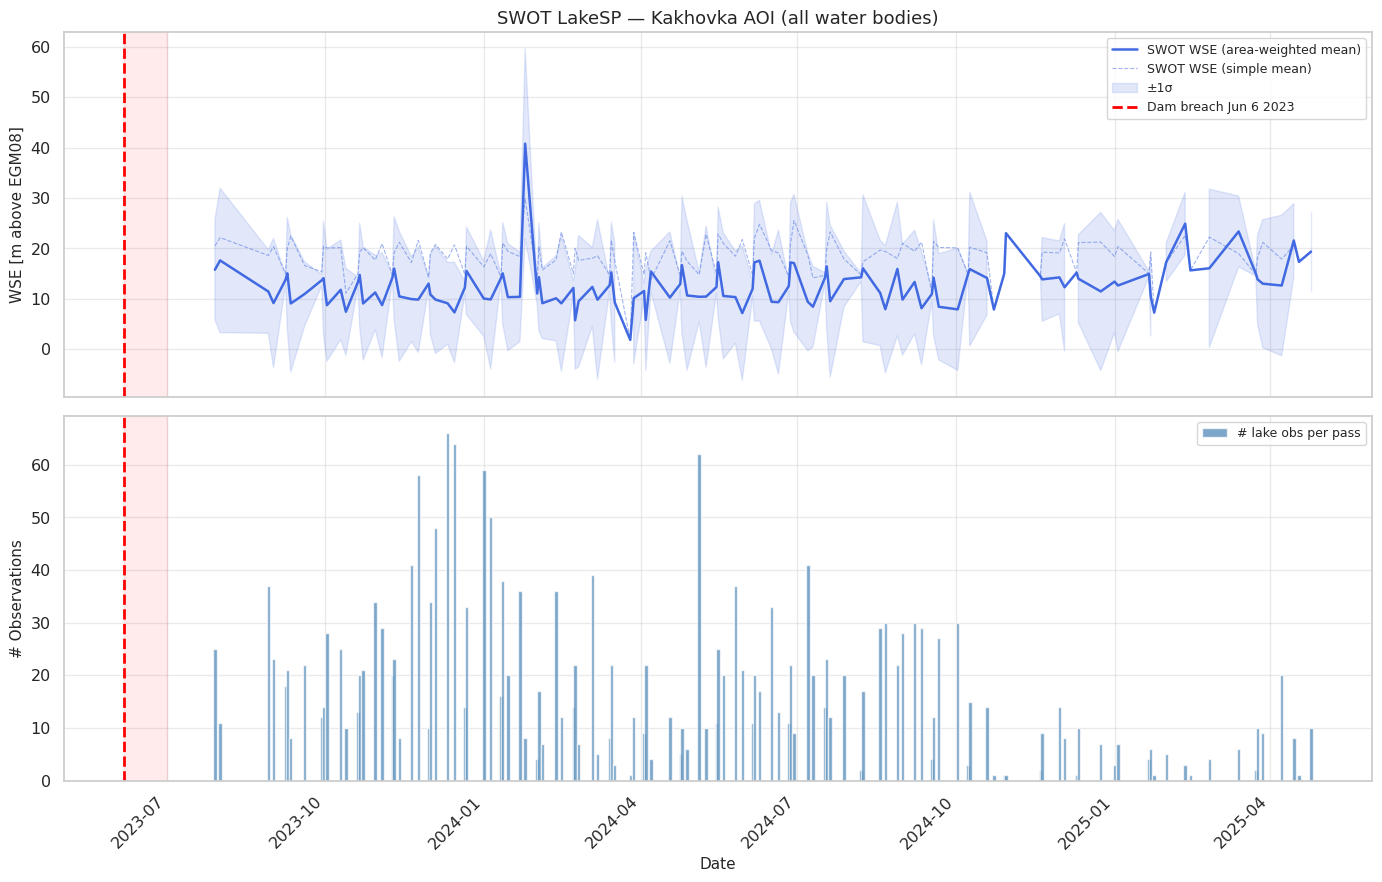

Saved: /mnt/c/Users/victo/PycharmProjects/SWOT-DNIPRO/data/figures/01_lakesp_wse_timeseries.png


In [9]:
if swot_lake_ts.empty:
    print("[SKIP] No LakeSP time series to plot.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

    ax = axes[0]
    ax.plot(swot_lake_ts['date'], swot_lake_ts['wse_area_wt'],
            color='royalblue', lw=1.8, zorder=3, label='SWOT WSE (area-weighted mean)')
    ax.plot(swot_lake_ts['date'], swot_lake_ts['wse_mean'],
            color='royalblue', lw=0.8, alpha=0.5, linestyle='--', label='SWOT WSE (simple mean)')

    if 'wse_std' in swot_lake_ts.columns:
        ax.fill_between(swot_lake_ts['date'],
                        swot_lake_ts['wse_area_wt'] - swot_lake_ts['wse_std'],
                        swot_lake_ts['wse_area_wt'] + swot_lake_ts['wse_std'],
                        alpha=0.15, color='royalblue', label='±1σ')

    ax.axvline(DAM_BREACH, color='red', lw=2, linestyle='--', label='Dam breach Jun 6 2023')
    ax.axvspan(DAM_BREACH, BREACH_END, alpha=0.08, color='red')
    ax.set_ylabel('WSE [m above EGM08]', fontsize=11)
    ax.set_title('SWOT LakeSP — Kakhovka AOI (all water bodies)', fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

    ax2 = axes[1]
    ax2.bar(swot_lake_ts['date'], swot_lake_ts['n_obs'],
            color='steelblue', alpha=0.7, width=2, label='# lake obs per pass')
    ax2.axvline(DAM_BREACH, color='red', lw=2, linestyle='--')
    ax2.axvspan(DAM_BREACH, BREACH_END, alpha=0.08, color='red')
    ax2.set_ylabel('# Observations', fontsize=11)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.4)

    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(FIG_DIR / '01_lakesp_wse_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {FIG_DIR / '01_lakesp_wse_timeseries.png'}")

## 7. Isolate Kakhovka Reservoir (WSE Filter)

The full LakeSP dataset includes all water bodies in the bbox (elevated lakes, ponds).
Kakhovka reservoir had WSE ≈ **7–15 m** above EGM08 before the breach, dropping to < 3 m after.
We filter to `1 < WSE < 20 m` to isolate the reservoir signal.

After WSE filter [1.0–20.0 m]: 1,401 rows  (was 2,192)


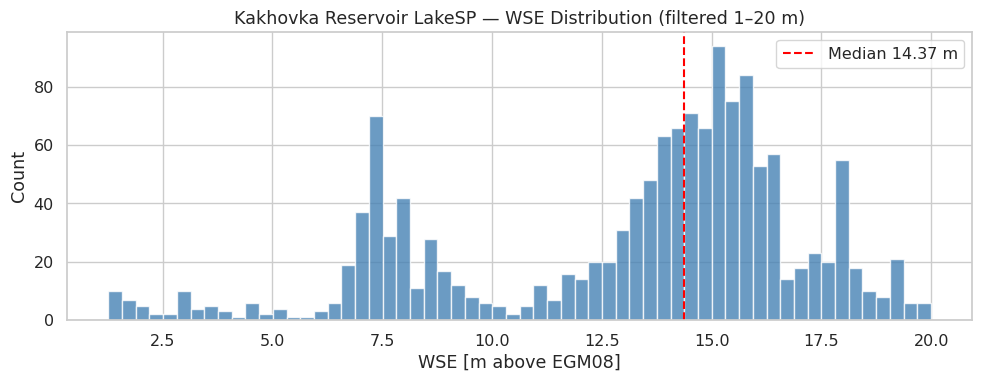


Top lake_id values (most observed):


,n_obs
lake_id,
2250085593,395
2250086362,91
2250087192,63
2250087272,49
2250087072,44
2250087122,42
2250086952,39
2250086402,38
2250087203,36


In [10]:
df_kakh = pd.DataFrame()
swot_kakh_ts = pd.DataFrame()

if df_lake.empty:
    print("[SKIP] No LakeSP data.")
else:
    # WSE range filter: reservoir-specific window
    mask_wse = (df_lake['wse'] >= KAKH_WSE_LO) & (df_lake['wse'] <= KAKH_WSE_HI)
    df_kakh = df_lake[mask_wse].copy()
    print(f"After WSE filter [{KAKH_WSE_LO}–{KAKH_WSE_HI} m]: {len(df_kakh):,} rows  "
          f"(was {len(df_lake):,})")

    if not df_kakh.empty:
        # WSE histogram to confirm reservoir peak
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.hist(df_kakh['wse'], bins=60, color='steelblue', alpha=0.8, edgecolor='white')
        ax.axvline(df_kakh['wse'].median(), color='red', lw=1.5, linestyle='--',
                   label=f"Median {df_kakh['wse'].median():.2f} m")
        ax.set_xlabel('WSE [m above EGM08]'); ax.set_ylabel('Count')
        ax.set_title('Kakhovka Reservoir LakeSP — WSE Distribution (filtered 1–20 m)')
        ax.legend()
        plt.tight_layout()
        plt.savefig(FIG_DIR / '07_kakh_wse_histogram.png', dpi=150, bbox_inches='tight')
        plt.show()

        # lake_id distribution
        if 'lake_id' in df_kakh.columns:
            top_ids = df_kakh['lake_id'].value_counts().head(10)
            print(f"\nTop lake_id values (most observed):")
            display(top_ids.rename('n_obs').to_frame())

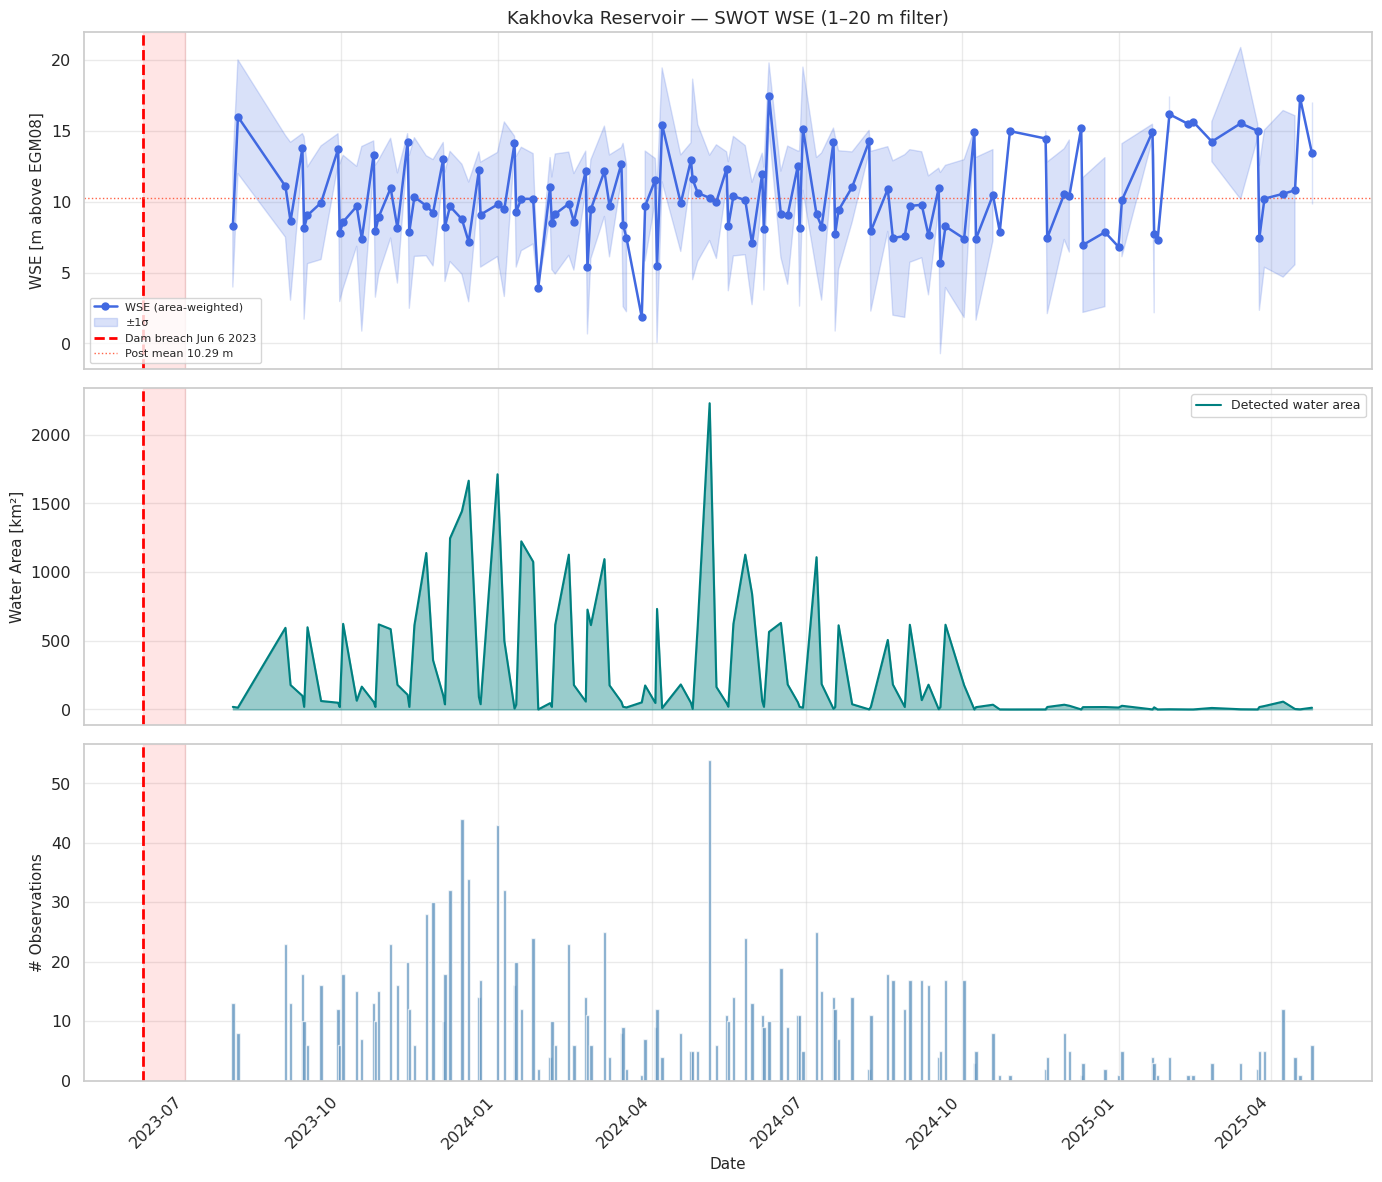

Saved: /mnt/c/Users/victo/PycharmProjects/SWOT-DNIPRO/data/figures/08_kakh_reservoir_timeseries.png

Kakhovka reservoir summary:
  Post-breach mean WSE: 10.293 m  (n=121 passes)


In [11]:
if not df_kakh.empty:
    # Time series for the reservoir
    if 'area_total' in df_kakh.columns:
        df_kakh['wse_x_area'] = df_kakh['wse'] * df_kakh['area_total']
        grp_k = df_kakh.groupby('date').agg(
            wse_mean=('wse', 'mean'),
            wse_area_wt=('wse_x_area', 'sum'),
            area_sum=('area_total', 'sum'),
            wse_std=('wse', 'std'),
            n_obs=('wse', 'count'),
            area_total=('area_total', 'sum'),
        ).reset_index()
        grp_k['wse_area_wt'] /= grp_k['area_sum'].clip(lower=1e-6)
    else:
        grp_k = df_kakh.groupby('date').agg(
            wse_mean=('wse', 'mean'),
            wse_std=('wse', 'std'),
            n_obs=('wse', 'count'),
        ).reset_index()
        grp_k['wse_area_wt'] = grp_k['wse_mean']

    grp_k['date'] = pd.to_datetime(grp_k['date'])
    swot_kakh_ts = grp_k.sort_values('date').reset_index(drop=True)

    # ── Figure: WSE + area time series ──────────────────────────────────────
    n_plots = 3 if 'area_total' in swot_kakh_ts.columns else 2
    fig, axes = plt.subplots(n_plots, 1, figsize=(14, 4*n_plots), sharex=True)

    ax = axes[0]
    ax.plot(swot_kakh_ts['date'], swot_kakh_ts['wse_area_wt'],
            'o-', color='royalblue', ms=5, lw=1.8, zorder=3,
            label='WSE (area-weighted)')
    if 'wse_std' in swot_kakh_ts.columns:
        ax.fill_between(swot_kakh_ts['date'],
                        swot_kakh_ts['wse_area_wt'] - swot_kakh_ts['wse_std'],
                        swot_kakh_ts['wse_area_wt'] + swot_kakh_ts['wse_std'],
                        alpha=0.2, color='royalblue', label='±1σ')
    ax.axvline(DAM_BREACH, color='red', lw=2, linestyle='--', label='Dam breach Jun 6 2023')
    ax.axvspan(DAM_BREACH, BREACH_END, alpha=0.1, color='red')
    ax.set_ylabel('WSE [m above EGM08]', fontsize=11)
    ax.set_title('Kakhovka Reservoir — SWOT WSE (1–20 m filter)', fontsize=13)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.4)

    pre  = swot_kakh_ts[swot_kakh_ts['date'] < DAM_BREACH]
    post = swot_kakh_ts[swot_kakh_ts['date'] >= BREACH_END]
    if not pre.empty:
        ax.axhline(pre['wse_area_wt'].mean(), color='royalblue', lw=1, linestyle=':',
                   label=f"Pre mean {pre['wse_area_wt'].mean():.2f} m")
    if not post.empty:
        ax.axhline(post['wse_area_wt'].mean(), color='tomato', lw=1, linestyle=':',
                   label=f"Post mean {post['wse_area_wt'].mean():.2f} m")
    ax.legend(fontsize=8)

    if 'area_total' in swot_kakh_ts.columns:
        ax2 = axes[1]
        ax2.fill_between(swot_kakh_ts['date'], swot_kakh_ts['area_total'],
                         alpha=0.4, color='teal')
        ax2.plot(swot_kakh_ts['date'], swot_kakh_ts['area_total'],
                 color='teal', lw=1.5, label='Detected water area')
        ax2.axvline(DAM_BREACH, color='red', lw=2, linestyle='--')
        ax2.axvspan(DAM_BREACH, BREACH_END, alpha=0.1, color='red')
        ax2.set_ylabel('Water Area [km²]', fontsize=11)
        ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)
        ax_n = axes[2]
    else:
        ax_n = axes[1]

    ax_n.bar(swot_kakh_ts['date'], swot_kakh_ts['n_obs'],
             color='steelblue', alpha=0.7, width=2)
    ax_n.axvline(DAM_BREACH, color='red', lw=2, linestyle='--')
    ax_n.axvspan(DAM_BREACH, BREACH_END, alpha=0.1, color='red')
    ax_n.set_ylabel('# Observations', fontsize=11)
    ax_n.set_xlabel('Date', fontsize=11)
    ax_n.grid(True, alpha=0.4)

    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(FIG_DIR / '08_kakh_reservoir_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {FIG_DIR / '08_kakh_reservoir_timeseries.png'}")

    print(f"\nKakhovka reservoir summary:")
    if not pre.empty:
        print(f"  Pre-breach mean WSE : {pre['wse_area_wt'].mean():.3f} m  (n={len(pre)} passes)")
    if not post.empty:
        print(f"  Post-breach mean WSE: {post['wse_area_wt'].mean():.3f} m  (n={len(post)} passes)")
    if not pre.empty and not post.empty:
        drop = pre['wse_area_wt'].mean() - post['wse_area_wt'].mean()
        print(f"  WSE drop            : {drop:.3f} m")

## 8. Water Surface Area Time Series (LakeSP)

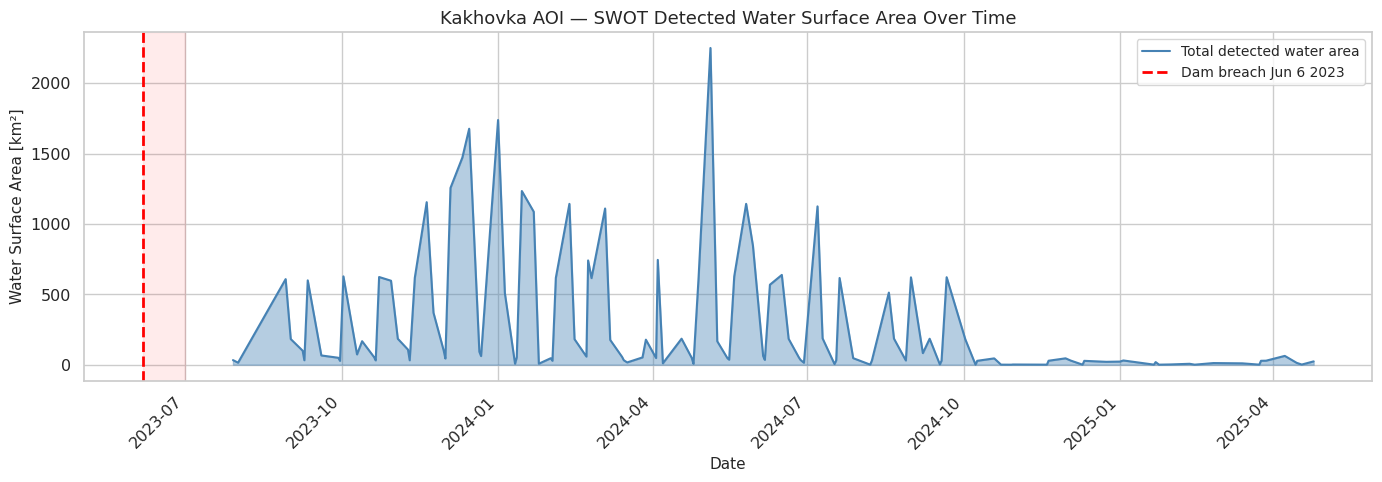

Saved: /mnt/c/Users/victo/PycharmProjects/SWOT-DNIPRO/data/figures/02_water_area_timeseries.png


In [12]:
if df_lake.empty or 'area_total' not in df_lake.columns:
    print("[SKIP] No area data available.")
else:
    area_ts = df_lake.groupby('date').agg(
        area_total_km2=('area_total', 'sum'),
        n_lakes=('lake_id', 'nunique') if 'lake_id' in df_lake.columns else ('wse','count'),
    ).reset_index()
    area_ts['date'] = pd.to_datetime(area_ts['date'])
    area_ts = area_ts.sort_values('date')

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.fill_between(area_ts['date'], area_ts['area_total_km2'],
                    alpha=0.4, color='steelblue')
    ax.plot(area_ts['date'], area_ts['area_total_km2'],
            color='steelblue', lw=1.5, label='Total detected water area')
    ax.axvline(DAM_BREACH, color='red', lw=2, linestyle='--', label='Dam breach Jun 6 2023')
    ax.axvspan(DAM_BREACH, BREACH_END, alpha=0.08, color='red')
    ax.set_ylabel('Water Surface Area [km²]', fontsize=11)
    ax.set_xlabel('Date', fontsize=11)
    ax.set_title('Kakhovka AOI — SWOT Detected Water Surface Area Over Time', fontsize=13)
    ax.legend(fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '02_water_area_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {FIG_DIR / '02_water_area_timeseries.png'}")

## 9. Dam Breach Analysis — Before vs After June 6, 2023

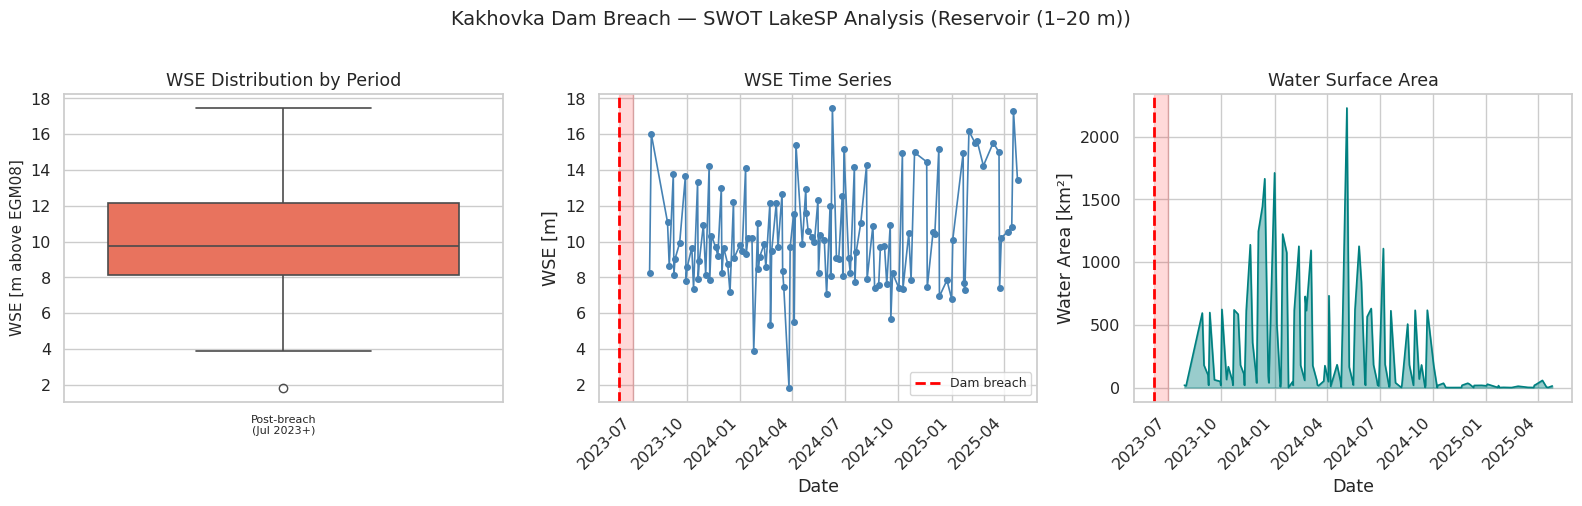

Saved: /mnt/c/Users/victo/PycharmProjects/SWOT-DNIPRO/data/figures/03_dam_breach_analysis.png

Summary Statistics per Period:


,n_passes,mean_wse,std_wse,min_wse,max_wse
period,,,,,
Post-breach\n(Jul 2023+),121,10.293,2.929,1.85,17.468


In [13]:
ts_for_breach = swot_kakh_ts if not swot_kakh_ts.empty else swot_lake_ts

if ts_for_breach.empty:
    print("[SKIP] No time series data for breach analysis.")
else:
    ts = ts_for_breach.copy()

    def label_period(d):
        if d < DAM_BREACH:
            return 'Pre-breach\n(Apr–Jun 5, 2023)'
        elif d <= BREACH_END:
            return 'Breach/drainage\n(Jun 6–Jul 1, 2023)'
        else:
            return 'Post-breach\n(Jul 2023+)'

    ts['period'] = ts['date'].apply(label_period)
    order = ['Pre-breach\n(Apr–Jun 5, 2023)',
             'Breach/drainage\n(Jun 6–Jul 1, 2023)',
             'Post-breach\n(Jul 2023+)']
    order = [o for o in order if o in ts['period'].values]
    palette = {'Pre-breach\n(Apr–Jun 5, 2023)': 'steelblue',
               'Breach/drainage\n(Jun 6–Jul 1, 2023)': 'gold',
               'Post-breach\n(Jul 2023+)': 'tomato'}

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Boxplot WSE
    ax = axes[0]
    sns.boxplot(data=ts, x='period', y='wse_area_wt',
                order=order, palette=palette, ax=ax, linewidth=1.2)
    ax.set_xlabel(''); ax.set_ylabel('WSE [m above EGM08]', fontsize=11)
    ax.set_title('WSE Distribution by Period')
    plt.setp(ax.xaxis.get_majorticklabels(), fontsize=8)

    # WSE timeline
    ax2 = axes[1]
    ax2.plot(ts['date'], ts['wse_area_wt'], 'o-',
             color='steelblue', ms=4, lw=1.2, zorder=3)
    ax2.axvline(DAM_BREACH, color='red', lw=2, linestyle='--', label='Dam breach')
    ax2.axvspan(DAM_BREACH, BREACH_END, alpha=0.15, color='red')
    ax2.set_xlabel('Date'); ax2.set_ylabel('WSE [m]')
    ax2.set_title('WSE Time Series')
    ax2.legend(fontsize=9)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Area timeline
    ax3 = axes[2]
    src_area = df_kakh if not df_kakh.empty else df_lake
    if 'area_total' in src_area.columns:
        area_ts2 = src_area.groupby('date')['area_total'].sum().reset_index()
        area_ts2['date'] = pd.to_datetime(area_ts2['date'])
        area_ts2 = area_ts2.sort_values('date')
        ax3.fill_between(area_ts2['date'], area_ts2['area_total'], alpha=0.4, color='teal')
        ax3.plot(area_ts2['date'], area_ts2['area_total'], color='teal', lw=1.2)
    ax3.axvline(DAM_BREACH, color='red', lw=2, linestyle='--', label='Dam breach')
    ax3.axvspan(DAM_BREACH, BREACH_END, alpha=0.15, color='red')
    ax3.set_xlabel('Date'); ax3.set_ylabel('Water Area [km²]')
    ax3.set_title('Water Surface Area')
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

    label_src = 'Reservoir (1–20 m)' if not swot_kakh_ts.empty else 'All water bodies'
    plt.suptitle(f'Kakhovka Dam Breach — SWOT LakeSP Analysis ({label_src})',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(FIG_DIR / '03_dam_breach_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {FIG_DIR / '03_dam_breach_analysis.png'}")

    summary = ts.groupby('period')['wse_area_wt'].agg(
        n_passes='count', mean_wse='mean', std_wse='std', min_wse='min', max_wse='max'
    ).round(3)
    print("\nSummary Statistics per Period:")
    display(summary)

## 10. Spatial Maps — Lake Observations (Kakhovka Reservoir)

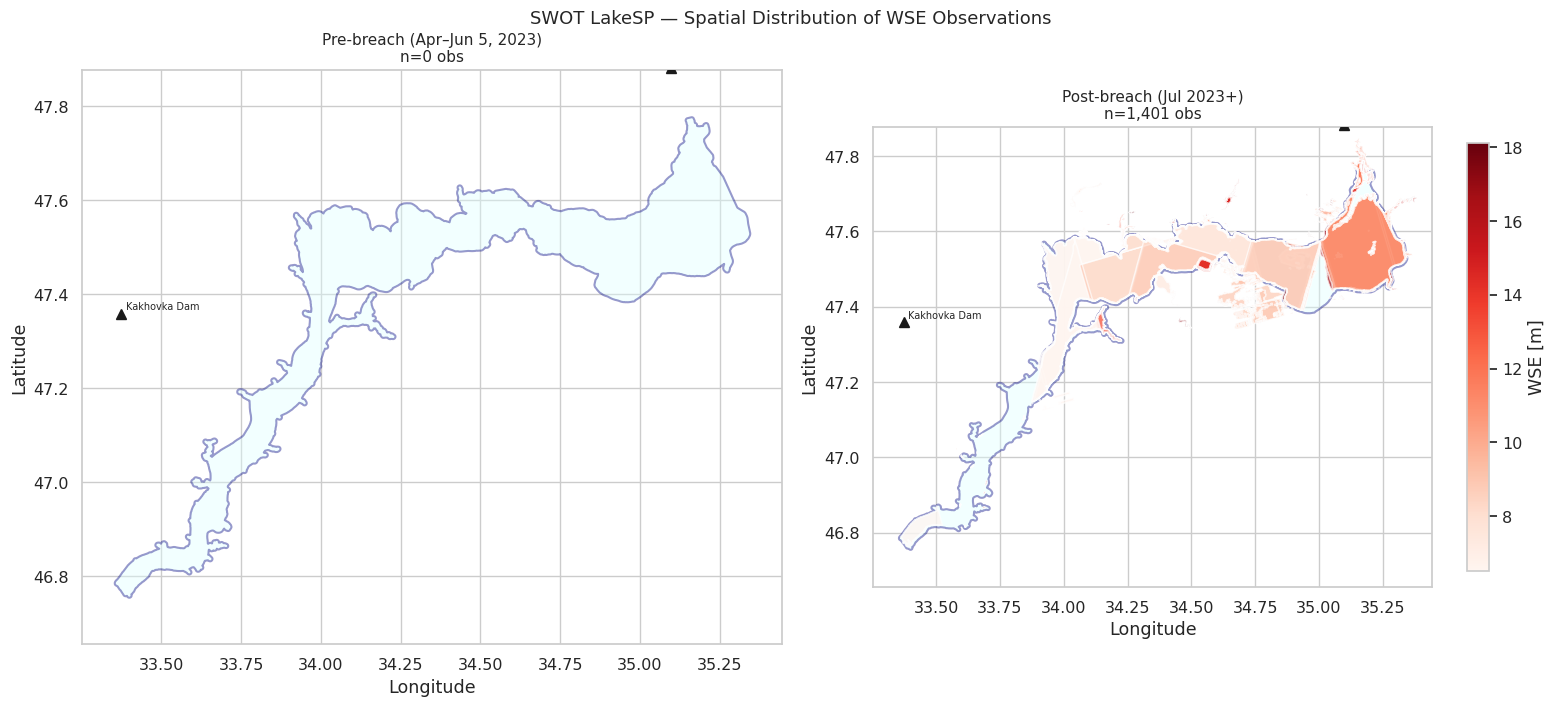

Saved: /mnt/c/Users/victo/PycharmProjects/SWOT-DNIPRO/data/figures/04_spatial_map_lakesp.png


In [14]:
src_df = df_kakh if not df_kakh.empty else df_lake

if src_df.empty:
    print("[SKIP] No LakeSP data to map.")
else:
    df_pre  = src_df[src_df['date'] < DAM_BREACH]
    df_post = src_df[src_df['date'] >= BREACH_END]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for ax, subset, title, cmap_name in [
        (axes[0], df_pre,  f'Pre-breach (Apr–Jun 5, 2023)\nn={len(df_pre):,} obs', 'Blues'),
        (axes[1], df_post, f'Post-breach (Jul 2023+)\nn={len(df_post):,} obs',     'Reds'),
    ]:
        gdf_sa.plot(ax=ax, facecolor='lightcyan', edgecolor='navy', lw=1.5, alpha=0.4)

        if not subset.empty and 'geometry' in subset.columns:
            gdf_sub = gpd.GeoDataFrame(subset, geometry='geometry', crs='EPSG:4326')
            wse_vals = gdf_sub['wse'].clip(lower=KAKH_WSE_LO, upper=KAKH_WSE_HI)
            vmin, vmax = wse_vals.quantile(0.05), wse_vals.quantile(0.95)
            gdf_sub.plot(column='wse', ax=ax, cmap=cmap_name,
                         vmin=vmin, vmax=vmax, alpha=0.7,
                         legend=True,
                         legend_kwds={'label': 'WSE [m]', 'shrink': 0.7})
        elif not subset.empty:
            # Fallback: scatter using geometry centroid if available
            ax.text(0.5, 0.5, f'{len(subset):,} obs\n(no geometry in subset)',
                    ha='center', va='center', transform=ax.transAxes, fontsize=10)

        for name, (lat, lon) in COORDS.items():
            ax.plot(lon, lat, 'k^', ms=7, zorder=5)
            ax.annotate(name, xy=(lon, lat), xytext=(3, 3),
                        textcoords='offset points', fontsize=7)

        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
        ax.set_xlim(bounds[0]-0.1, bounds[2]+0.1)
        ax.set_ylim(bounds[1]-0.1, bounds[3]+0.1)

    plt.suptitle('SWOT LakeSP — Spatial Distribution of WSE Observations', fontsize=13)
    plt.tight_layout()
    plt.savefig(FIG_DIR / '04_spatial_map_lakesp.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {FIG_DIR / '04_spatial_map_lakesp.png'}")

## 11. RiverSP — Lower Dnipro River Reaches

In [15]:
RIVER_BBOX = (31.5, 46.2, 35.5, 47.8)   # (minlon, minlat, maxlon, maxlat)

RIVER_COLS = ['time_utc','wse','wse_u','width','slope','dschg_c','reach_id',
              'river_name','p_lat','p_lon','reach_q','geoid_hght','geometry']

def _load_one_river(shp_path, bbox, max_q=1):
    minlon, minlat, maxlon, maxlat = bbox
    try:
        gdf = gpd.read_file(shp_path, bbox=bbox)
        if gdf.empty or 'wse' not in gdf.columns:
            return None
        if 'p_lat' in gdf.columns and 'p_lon' in gdf.columns:
            mask = ((gdf['p_lon'] >= minlon) & (gdf['p_lon'] <= maxlon) &
                    (gdf['p_lat'] >= minlat) & (gdf['p_lat'] <= maxlat))
            gdf = gdf[mask]
        if 'reach_q' in gdf.columns:
            gdf = gdf[gdf['reach_q'] <= max_q]
        gdf = _filter_wse(gdf)
        if gdf.empty:
            return None
        gdf = _parse_time(gdf)
        keep = [c for c in RIVER_COLS if c in gdf.columns]
        return gdf[keep].copy()
    except Exception:
        return None

def load_all_riversp(shp_list, bbox, max_workers=8):
    frames = []
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futs = {pool.submit(_load_one_river, s, bbox): s for s in shp_list}
        for fut in as_completed(futs):
            r = fut.result()
            if r is not None:
                frames.append(r)
    print(f"  Files with data: {len(frames)}")
    if not frames:
        return gpd.GeoDataFrame()
    result = pd.concat(frames, ignore_index=True)
    if 'geometry' in result.columns:
        result = gpd.GeoDataFrame(result, geometry='geometry', crs='EPSG:4326')
    return result

print("Batch loading RiverSP (parallel) …")
df_river = load_all_riversp(riversp_shps, RIVER_BBOX)
print(f"Total RiverSP rows in bbox: {len(df_river):,}")
if not df_river.empty:
    display(df_river.drop(columns='geometry', errors='ignore').head(5))

Batch loading RiverSP (parallel) …


  Files with data: 319
Total RiverSP rows in bbox: 5,055


,time_utc,wse,wse_u,width,slope,dschg_c,reach_id,river_name,p_lat,p_lon,reach_q,geoid_hght
0,2023-04-06 21:16:46+00:00,0.0524,0.09593,4349.558059,5.746000e-07,-1.000000e+12,22400900025,no_data,46.587437,31.604386,1,25.887573
1,2023-04-06 21:16:46+00:00,0.0803,0.10295,5636.517947,-2.514000e-07,-1.000000e+12,22400900035,no_data,46.577293,31.828283,1,25.392678
2,2023-04-06 21:16:47+00:00,0.4492,0.09003,734.506054,3.030359e-05,-1.000000e+12,22511100021,Dnipro,46.677573,32.803218,1,23.850462
3,2023-04-06 21:16:47+00:00,0.3746,0.09294,1277.860178,8.793280e-06,-1.000000e+12,22511100055,Dnipro,46.636325,32.720145,1,23.972994
4,2023-04-06 21:16:47+00:00,0.4282,0.09010,1965.600698,-2.765140e-05,-1.000000e+12,22511300011,Dnipro,46.690086,32.839273,1,23.778360


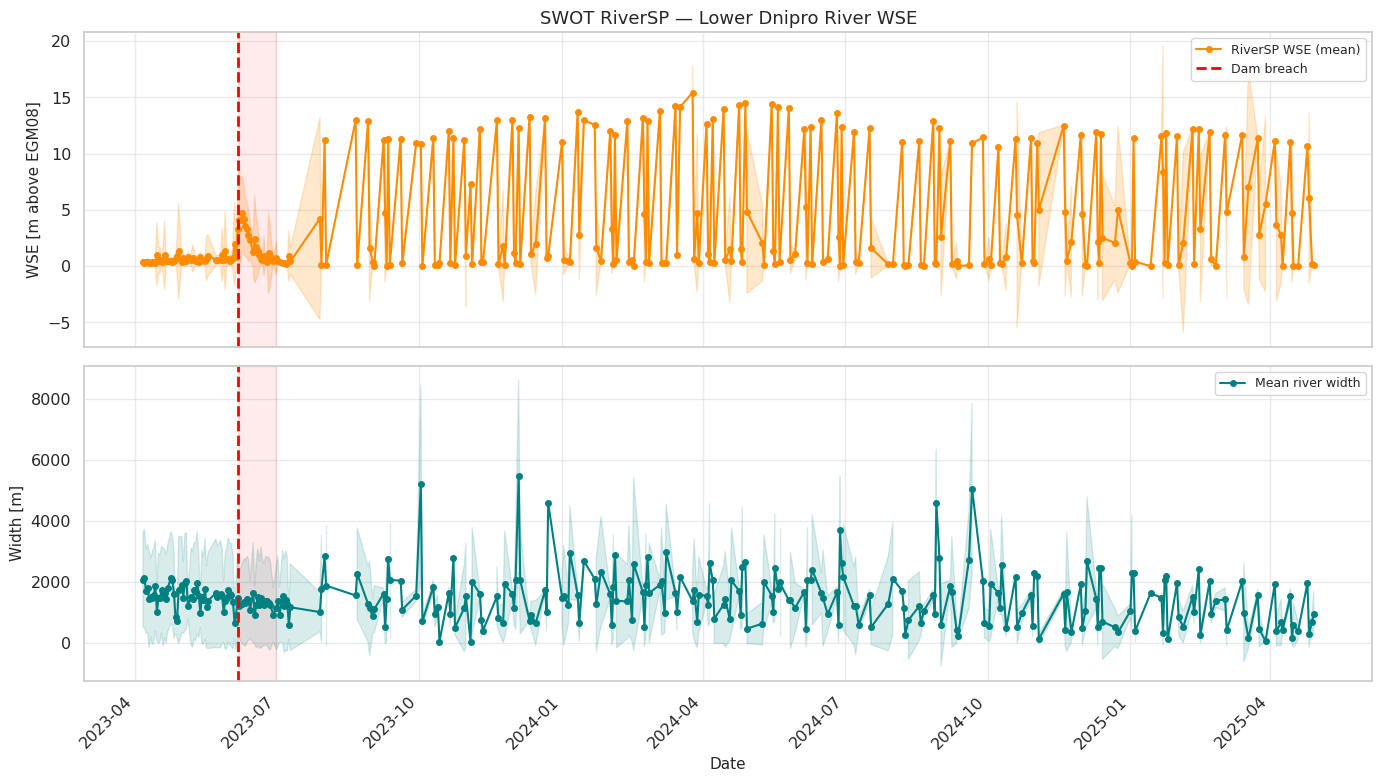

Saved: /mnt/c/Users/victo/PycharmProjects/SWOT-DNIPRO/data/figures/05_riversp_wse_timeseries.png


In [16]:
swot_river_ts = pd.DataFrame()

if df_river.empty:
    print("[SKIP] No RiverSP data loaded.")
else:
    df_river['date'] = df_river['time_utc'].dt.tz_localize(None).dt.normalize()

    agg_dict = {'wse': ['mean', 'std', 'count']}
    if 'width' in df_river.columns:
        agg_dict['width'] = ['mean', 'std']

    grp_r = df_river.groupby('date').agg({
        'wse': ['mean', 'std', 'count'],
        **({'width': ['mean', 'std']} if 'width' in df_river.columns else {})
    })
    grp_r.columns = ['_'.join(c).strip() for c in grp_r.columns]
    grp_r = grp_r.rename(columns={
        'wse_mean': 'wse_mean', 'wse_std': 'wse_std', 'wse_count': 'n_obs',
        'width_mean': 'width_mean', 'width_std': 'width_std',
    })
    swot_river_ts = grp_r.reset_index().rename(columns={'date': 'date'})
    swot_river_ts['date'] = pd.to_datetime(swot_river_ts['date'])

    n_panels = 2 if 'width_mean' in swot_river_ts.columns else 1
    fig, axes = plt.subplots(n_panels, 1, figsize=(14, 4*n_panels), sharex=True)
    if n_panels == 1:
        axes = [axes]

    ax = axes[0]
    ax.plot(swot_river_ts['date'], swot_river_ts['wse_mean'],
            'o-', color='darkorange', ms=4, lw=1.5, label='RiverSP WSE (mean)')
    if 'wse_std' in swot_river_ts.columns:
        ax.fill_between(swot_river_ts['date'],
                        swot_river_ts['wse_mean'] - swot_river_ts['wse_std'],
                        swot_river_ts['wse_mean'] + swot_river_ts['wse_std'],
                        alpha=0.2, color='darkorange')
    ax.axvline(DAM_BREACH, color='red', lw=2, linestyle='--', label='Dam breach')
    ax.axvspan(DAM_BREACH, BREACH_END, alpha=0.08, color='red')
    ax.set_ylabel('WSE [m above EGM08]', fontsize=11)
    ax.set_title('SWOT RiverSP — Lower Dnipro River WSE', fontsize=13)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.4)

    if n_panels > 1:
        ax2 = axes[1]
        ax2.plot(swot_river_ts['date'], swot_river_ts['width_mean'],
                 'o-', color='teal', ms=4, lw=1.5, label='Mean river width')
        if 'width_std' in swot_river_ts.columns:
            ax2.fill_between(swot_river_ts['date'],
                             swot_river_ts['width_mean'] - swot_river_ts['width_std'],
                             swot_river_ts['width_mean'] + swot_river_ts['width_std'],
                             alpha=0.15, color='teal')
        ax2.axvline(DAM_BREACH, color='red', lw=2, linestyle='--')
        ax2.axvspan(DAM_BREACH, BREACH_END, alpha=0.08, color='red')
        ax2.set_ylabel('Width [m]', fontsize=11)
        ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)
    axes[-1].set_xlabel('Date', fontsize=11)

    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(FIG_DIR / '05_riversp_wse_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {FIG_DIR / '05_riversp_wse_timeseries.png'}")

## 12. RiverSP Flooding Analysis — River Width Anomaly

**Method:** Compute a pre-breach baseline width per reach (mean of all pre-breach observations).
The **width anomaly** = observed width − baseline.
Positive anomaly → river wider than normal → potential flooding.

> Note: SWOT started observing this area in April 2023, so pre-breach baseline covers
> approximately April–June 5, 2023 (≈8 weeks).

Reaches with ≥2 pre-breach observations: 51
Rows after baseline merge: 4,709


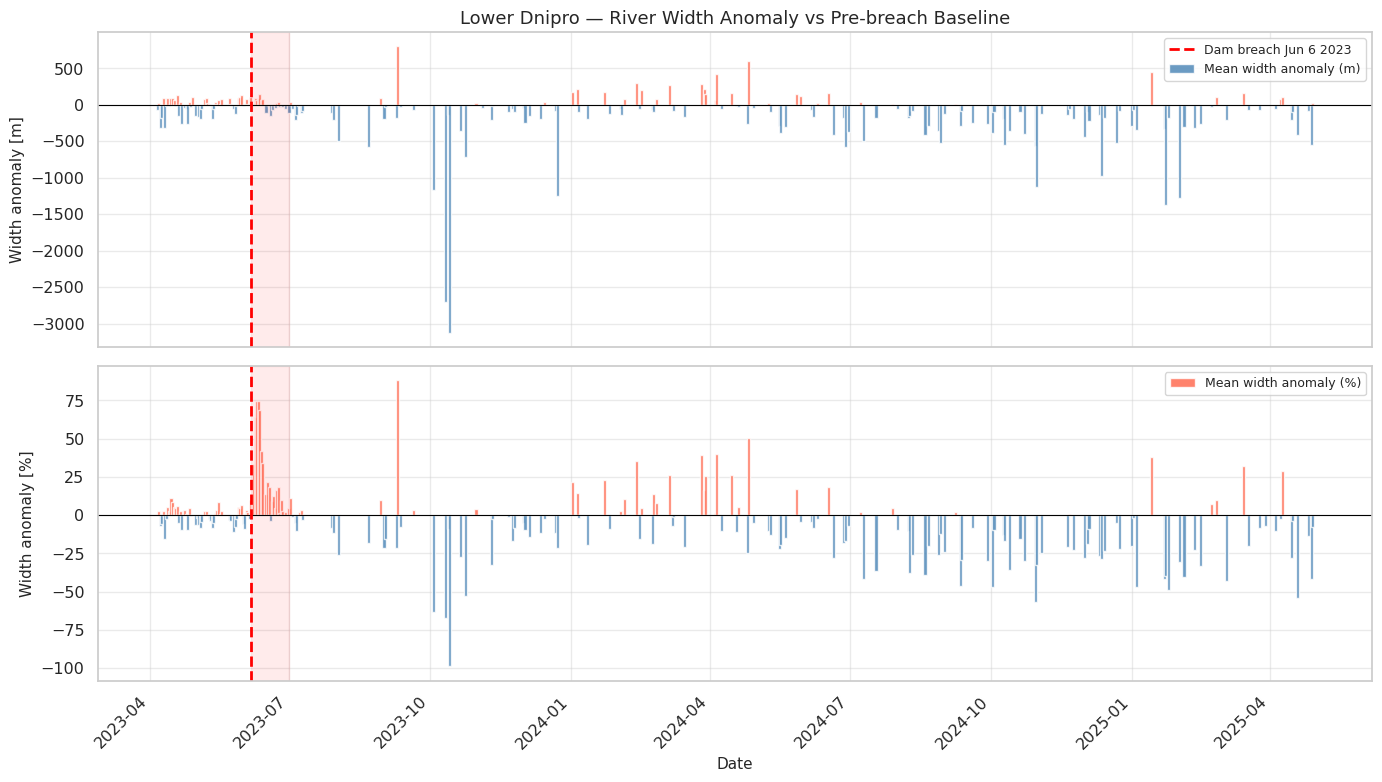

Saved: /mnt/c/Users/victo/PycharmProjects/SWOT-DNIPRO/data/figures/09_riversp_width_anomaly.png


In [17]:
df_width_anomaly = pd.DataFrame()

if df_river.empty or 'width' not in df_river.columns or 'reach_id' not in df_river.columns:
    print("[SKIP] Width or reach_id not available in RiverSP data.")
else:
    df_r = df_river[df_river['width'].notna() & (df_river['width'] > 0)].copy()

    # Pre-breach baseline: mean width per reach
    pre_mask = df_r['date'] < DAM_BREACH
    baseline = (
        df_r[pre_mask]
        .groupby('reach_id')['width']
        .agg(width_baseline='mean', n_baseline='count')
        .reset_index()
    )
    baseline = baseline[baseline['n_baseline'] >= 2]  # need ≥2 pre-breach passes
    print(f"Reaches with ≥2 pre-breach observations: {len(baseline):,}")

    # Merge baseline into all observations
    df_r = df_r.merge(baseline[['reach_id','width_baseline']], on='reach_id', how='inner')
    df_r['width_anomaly'] = df_r['width'] - df_r['width_baseline']
    df_r['width_anomaly_pct'] = 100.0 * df_r['width_anomaly'] / df_r['width_baseline'].clip(lower=1)

    df_width_anomaly = df_r.copy()
    print(f"Rows after baseline merge: {len(df_r):,}")

    # Daily mean anomaly
    anom_ts = df_r.groupby('date').agg(
        width_anom_mean=('width_anomaly', 'mean'),
        width_anom_pct=('width_anomaly_pct', 'mean'),
        n_reaches=('reach_id', 'nunique'),
    ).reset_index()
    anom_ts['date'] = pd.to_datetime(anom_ts['date'])

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    ax = axes[0]
    ax.bar(anom_ts['date'], anom_ts['width_anom_mean'],
           color=np.where(anom_ts['width_anom_mean'] > 0, 'tomato', 'steelblue'),
           alpha=0.8, width=2, label='Mean width anomaly (m)')
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(DAM_BREACH, color='red', lw=2, linestyle='--', label='Dam breach Jun 6 2023')
    ax.axvspan(DAM_BREACH, BREACH_END, alpha=0.08, color='red')
    ax.set_ylabel('Width anomaly [m]', fontsize=11)
    ax.set_title('Lower Dnipro — River Width Anomaly vs Pre-breach Baseline', fontsize=13)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.4)

    ax2 = axes[1]
    ax2.bar(anom_ts['date'], anom_ts['width_anom_pct'],
            color=np.where(anom_ts['width_anom_pct'] > 0, 'tomato', 'steelblue'),
            alpha=0.8, width=2, label='Mean width anomaly (%)')
    ax2.axhline(0, color='black', lw=0.8)
    ax2.axvline(DAM_BREACH, color='red', lw=2, linestyle='--')
    ax2.axvspan(DAM_BREACH, BREACH_END, alpha=0.08, color='red')
    ax2.set_ylabel('Width anomaly [%]', fontsize=11)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)

    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(FIG_DIR / '09_riversp_width_anomaly.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {FIG_DIR / '09_riversp_width_anomaly.png'}")

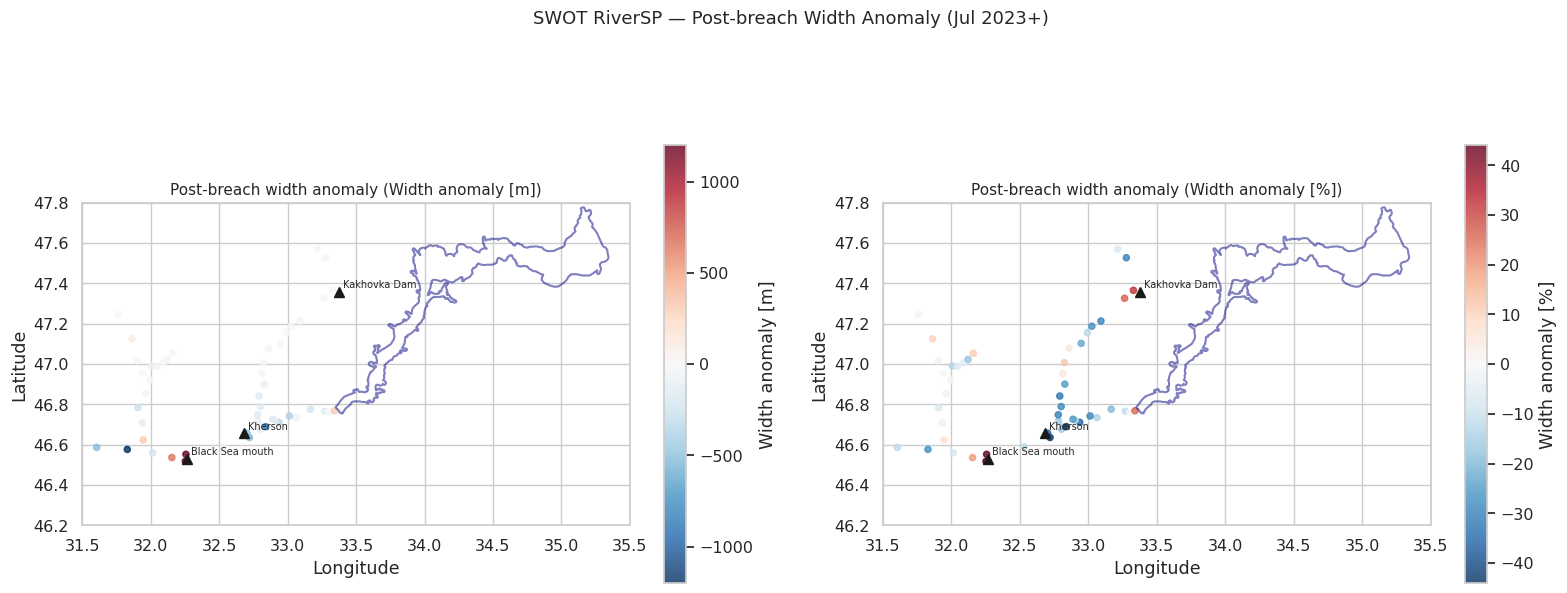

Saved: /mnt/c/Users/victo/PycharmProjects/SWOT-DNIPRO/data/figures/10_riversp_flood_spatial.png

Top 10 reaches with largest post-breach width increase:


,reach_id,p_lat,p_lon,width_anom_mean,width_anom_pct
34,22601000035,46.52,32.25,3106.48,347.45
33,22601000025,46.55,32.26,3186.10,274.10
20,22511200201,47.37,33.33,11.92,31.82
19,22511200181,47.33,33.26,7.39,25.98
32,22511300111,46.77,33.34,299.22,25.43
36,22601000065,46.54,32.15,637.90,18.65
13,22511200071,47.01,32.83,15.52,11.52
47,22602200055,47.05,32.16,12.94,10.80
49,22602300105,47.13,31.86,92.61,9.78
42,22602100065,46.62,31.94,304.67,6.81


In [18]:
# Spatial map: post-breach width anomaly per reach centroid
if not df_width_anomaly.empty and 'p_lat' in df_width_anomaly.columns:
    # Post-breach mean anomaly per reach
    post_anom = (
        df_width_anomaly[df_width_anomaly['date'] >= BREACH_END]
        .groupby('reach_id').agg(
            width_anom_mean=('width_anomaly', 'mean'),
            width_anom_pct=('width_anomaly_pct', 'mean'),
            p_lat=('p_lat', 'mean'),
            p_lon=('p_lon', 'mean'),
        ).reset_index()
    )

    if not post_anom.empty:
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))

        for ax, col, label, cmap in [
            (axes[0], 'width_anom_mean', 'Width anomaly [m]',   'RdBu_r'),
            (axes[1], 'width_anom_pct',  'Width anomaly [%]',   'RdBu_r'),
        ]:
            vmax = post_anom[col].abs().quantile(0.95)
            sc = ax.scatter(post_anom['p_lon'], post_anom['p_lat'],
                            c=post_anom[col], cmap=cmap,
                            s=20, alpha=0.8, vmin=-vmax, vmax=vmax)
            plt.colorbar(sc, ax=ax, label=label, shrink=0.7)

            # AOI polygon
            gdf_sa.boundary.plot(ax=ax, color='navy', lw=1.5, alpha=0.5)

            for name, (lat, lon) in COORDS.items():
                ax.plot(lon, lat, 'k^', ms=7, zorder=5)
                ax.annotate(name, xy=(lon, lat), xytext=(3, 3),
                            textcoords='offset points', fontsize=7)

            ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
            ax.set_title(f'Post-breach width anomaly ({label})', fontsize=11)
            minlon, minlat, maxlon, maxlat = RIVER_BBOX
            ax.set_xlim(minlon, maxlon); ax.set_ylim(minlat, maxlat)

        plt.suptitle('SWOT RiverSP — Post-breach Width Anomaly (Jul 2023+)', fontsize=13)
        plt.tight_layout()
        plt.savefig(FIG_DIR / '10_riversp_flood_spatial.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: {FIG_DIR / '10_riversp_flood_spatial.png'}")

        # Top flooded reaches
        top_flood = post_anom.nlargest(10, 'width_anom_pct')[
            ['reach_id','p_lat','p_lon','width_anom_mean','width_anom_pct']
        ].round(2)
        print("\nTop 10 reaches with largest post-breach width increase:")
        display(top_flood)

## 12b. Convert SWOT WSE: EGM08 → EGG2015 (EVRS)

SWOT reports WSE above the **EGM08** geoid. To compare with gauge data in
the **Baltic height system (BS-77)** or EVRS, convert to **EGG2015**:

```
H_ellipsoid  = wse + geoid_hght        # geoid_hght = N_EGM08 stored in shapefile
N_EGG2015    = sample(egg_2015.tif, lon, lat)
wse_EGG2015  = H_ellipsoid − N_EGG2015
```

EGG2015 ≈ BS-77 within **< 10 cm** in the Dnipro region, so the corrected
WSE can be directly compared to gauge levels.

In [19]:
import rasterio
from rasterio.sample import sample_gen as rio_sample

EGG2015_PATH = DATA_DIR / 'egg_2015.tif'

def add_wse_egg2015(df, lon_col='p_lon', lat_col='p_lat',
                    geoid_col='geoid_hght', wse_col='wse'):
    """Add wse_egg2015 column to a DataFrame."""
    if not EGG2015_PATH.exists():
        print(f"[SKIP] egg_2015.tif not found at {EGG2015_PATH}")
        return df
    if geoid_col not in df.columns:
        print(f"[SKIP] Column '{geoid_col}' not in DataFrame")
        return df

    df = df.copy()

    # Get lon/lat — use centroid for lake polygons if no explicit coord columns
    if lon_col in df.columns and lat_col in df.columns:
        lons = df[lon_col].values
        lats = df[lat_col].values
    elif 'geometry' in df.columns:
        centroids = gpd.GeoSeries(df['geometry']).centroid
        lons = centroids.x.values
        lats = centroids.y.values
    else:
        print("[SKIP] No coordinate columns or geometry available")
        return df

    coords = list(zip(lons, lats))
    with rasterio.open(EGG2015_PATH) as src:
        n_egg = np.array([v[0] for v in rio_sample(src, coords)], dtype=float)

    # Mask nodata (fill value in geoid grids is often -9999 or 0 outside coverage)
    n_egg = np.where(np.abs(n_egg) > 1000, np.nan, n_egg)

    geoid_egm08 = df[geoid_col].replace(-9.99e20, np.nan).values
    valid = ~(np.isnan(geoid_egm08) | np.isnan(n_egg))
    df['n_egg2015'] = np.where(valid, n_egg, np.nan)
    df['n_egm08']   = np.where(valid, geoid_egm08, np.nan)
    df['h_ellipsoid'] = np.where(valid, df[wse_col] + geoid_egm08, np.nan)
    df['wse_egg2015'] = np.where(valid, df['h_ellipsoid'] - n_egg, np.nan)
    return df

print(f"egg_2015.tif present: {EGG2015_PATH.exists()}")

# ── Apply to RiverSP (has p_lat / p_lon columns) ────────────────────────────
if not df_river.empty and 'geoid_hght' in df_river.columns:
    print("Converting RiverSP WSE to EGG2015 ...")
    df_river = add_wse_egg2015(df_river, lon_col='p_lon', lat_col='p_lat',
                                geoid_col='geoid_hght', wse_col='wse')
    valid_conv = df_river['wse_egg2015'].notna().sum()
    diff = (df_river['wse_egg2015'] - df_river['wse']).dropna()
    print(f"  Converted {valid_conv:,} RiverSP observations")
    print(f"  EGG2015 − EGM08 offset: mean={diff.mean():.4f} m  "
          f"std={diff.std():.4f} m  range=[{diff.min():.4f}, {diff.max():.4f}]")

# ── Apply to LakeSP (use geometry centroid) ──────────────────────────────────
if not df_kakh.empty and 'geoid_hght' in df_kakh.columns:
    print("Converting LakeSP (Kakhovka) WSE to EGG2015 ...")
    df_kakh = add_wse_egg2015(df_kakh, geoid_col='geoid_hght', wse_col='wse')
    if 'wse_egg2015' in df_kakh.columns:
        diff_l = (df_kakh['wse_egg2015'] - df_kakh['wse']).dropna()
        print(f"  EGG2015 − EGM08 offset at Kakhovka: mean={diff_l.mean():.4f} m")
elif not df_lake.empty and 'geoid_hght' in df_lake.columns:
    print("Converting LakeSP (all AOI) WSE to EGG2015 ...")
    df_lake = add_wse_egg2015(df_lake, geoid_col='geoid_hght', wse_col='wse')

egg_2015.tif present: True
Converting RiverSP WSE to EGG2015 ...


  Converted 5,055 RiverSP observations
  EGG2015 − EGM08 offset: mean=0.1606 m  std=0.0311 m  range=[-0.0300, 0.3231]
Converting LakeSP (Kakhovka) WSE to EGG2015 ...


  EGG2015 − EGM08 offset at Kakhovka: mean=0.1734 m


EGG2015 undulation at Херсон gauge (46.6360°N, 32.6190°E): 24.0200 m
Gauge zero elevation in EVRS ≈ -5.00 m + (BS77 datum correction, typically < 0.1 m)

Note: stations 80959–80977 (Kakhovka reservoir) are NOT in the
available ГІДРОЛОГІЯ_2023 yearbook (occupied territory in 2023).
Time series data for those stations requires a separate data source.


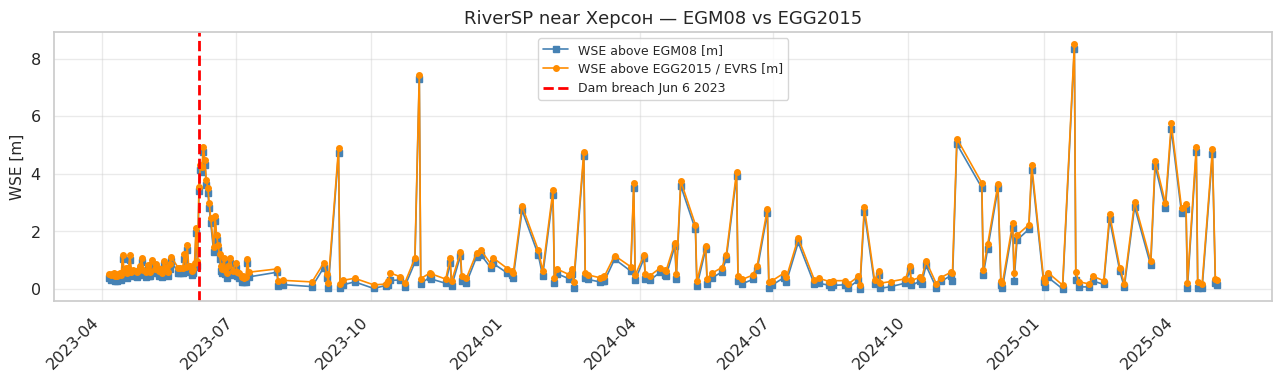

Saved: /mnt/c/Users/victo/PycharmProjects/SWOT-DNIPRO/data/figures/12_wse_geoid_comparison.png


In [20]:
# ── Gauge BS-77 → EVRS conversion ───────────────────────────────────────────
# BS-77 ≈ EVRS (EGG2015) within < 10 cm for Ukraine.
# Practical formula for station 80805 (Херсон):
#   Gauge zero datum: -5.00 m BS-77
#   H_BS77 = level_cm / 100 + (-5.00)
#   H_EVRS ≈ H_BS77  (correction negligible relative to SWOT uncertainty)
#
# For precise conversion: sample EGG2015 at gauge location
if EGG2015_PATH.exists():
    lat_g, lon_g = GAUGE_STATION['lat'], GAUGE_STATION['lon']
    with rasterio.open(EGG2015_PATH) as src:
        n_egg_gauge = list(rio_sample(src, [(lon_g, lat_g)]))[0][0]
    print(f"EGG2015 undulation at Херсон gauge ({lat_g:.4f}°N, {lon_g:.4f}°E): "
          f"{n_egg_gauge:.4f} m")
    print(f"Gauge zero elevation in EVRS ≈ {-5.00:.2f} m + "
          f"(BS77 datum correction, typically < 0.1 m)")
    print()
    print("Note: stations 80959–80977 (Kakhovka reservoir) are NOT in the")
    print("available ГІДРОЛОГІЯ_2023 yearbook (occupied territory in 2023).")
    print("Time series data for those stations requires a separate data source.")

if not df_river.empty and 'wse_egg2015' in df_river.columns:
    # Plot EGM08 vs EGG2015 RiverSP time series near Kherson
    lat0, lon0 = GAUGE_STATION['lat'], GAUGE_STATION['lon']
    mask_near = (
        (df_river['p_lat'] >= lat0 - 1.0) & (df_river['p_lat'] <= lat0 + 1.0) &
        (df_river['p_lon'] >= lon0 - 1.0) & (df_river['p_lon'] <= lon0 + 1.0)
    )
    df_near2 = df_river[mask_near].dropna(subset=['wse_egg2015'])

    if not df_near2.empty:
        ts_egm = df_near2.groupby('date')['wse'].mean()
        ts_egg = df_near2.groupby('date')['wse_egg2015'].mean()

        fig, ax = plt.subplots(figsize=(13, 4))
        ax.plot(ts_egm.index, ts_egm.values, 's-', color='steelblue', ms=4,
                lw=1.2, label='WSE above EGM08 [m]')
        ax.plot(ts_egg.index, ts_egg.values, 'o-', color='darkorange', ms=4,
                lw=1.2, label='WSE above EGG2015 / EVRS [m]')
        ax.axvline(DAM_BREACH, color='red', lw=2, linestyle='--',
                   label='Dam breach Jun 6 2023')
        ax.set_ylabel('WSE [m]', fontsize=11)
        ax.set_title('RiverSP near Херсон — EGM08 vs EGG2015', fontsize=13)
        ax.legend(fontsize=9); ax.grid(True, alpha=0.4)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(FIG_DIR / '12_wse_geoid_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: {FIG_DIR / '12_wse_geoid_comparison.png'}")

## 13. Gauge vs SWOT — р.Дніпро м.Херсон (2023)

**Data source:** Ukrainian Hydrological Yearbook 2023, station 80805 (р.Дніпро - м.Херсон).
Gauge datum: −5.00 m BS-77. Values are daily water level in **cm above gauge zero**.

> Note: Gauge is in BS-77 height system, SWOT WSE is above EGM08 geoid.
> The systems differ by ~20–40 cm near Kherson; we compare **relative changes** (anomalies).

In [21]:
df_gauge = pd.DataFrame()

def parse_table12_xls(filepath, year=2023):
    """Parse Ukrainian hydrological yearbook Table 1.2 daily water level."""
    import xlrd
    wb = xlrd.open_workbook(str(filepath))
    ws = wb.sheet_by_index(0)

    # Find month header row (contains 12 consecutive integers 1-12)
    month_col = {}
    for r in range(ws.nrows):
        row = ws.row_values(r)
        nums = [(c, int(v)) for c, v in enumerate(row)
                if isinstance(v, float) and v == int(v) and 1 <= v <= 12]
        if len(nums) >= 6:
            for c, m in nums:
                month_col[m] = c
            break

    if not month_col:
        print("[WARN] Could not find month header row in", filepath)
        return pd.DataFrame()

    records = []
    for r in range(ws.nrows):
        row = ws.row_values(r)
        day_val = row[0]
        if not isinstance(day_val, float) or not (1 <= day_val <= 31):
            continue
        day = int(day_val)
        for month, col in month_col.items():
            if col >= len(row):
                continue
            v = row[col]
            level = None
            if isinstance(v, str):
                # Strip quality codes: ), :, Z, I, * etc.
                cleaned = re.sub(r'[^0-9.\-]', '', v.strip())
                try:
                    level = float(cleaned) if cleaned else None
                except ValueError:
                    level = None
            elif isinstance(v, (int, float)) and v not in ('', None):
                level = float(v) if abs(v) < 1e10 else None
            if level is not None and -500 < level < 5000:
                try:
                    records.append({
                        'date': pd.Timestamp(year=year, month=month, day=day),
                        'level_cm': level,
                    })
                except ValueError:
                    pass  # invalid date (e.g. Feb 30)

    df = pd.DataFrame(records).sort_values('date').reset_index(drop=True)
    # Absolute WSE in BS-77: datum is -5.00 m
    df['wse_bs77_m'] = df['level_cm'] / 100.0 + (-5.00)
    return df

if not HAS_XLRD:
    print("[SKIP] xlrd not installed.")
elif not GAUGE_XLS.exists():
    print(f"[SKIP] Gauge file not found: {GAUGE_XLS}")
else:
    df_gauge = parse_table12_xls(GAUGE_XLS, year=2023)
    print(f"Gauge 80805 (Херсон) — {len(df_gauge)} daily observations")
    print(f"Date range: {df_gauge['date'].min().date()} → {df_gauge['date'].max().date()}")
    display(df_gauge.head(8))

Gauge 80805 (Херсон) — 365 daily observations
Date range: 2023-01-01 → 2023-12-31


,date,level_cm,wse_bs77_m
0,2023-01-01,521.0,0.21
1,2023-01-02,521.0,0.21
2,2023-01-03,523.0,0.23
3,2023-01-04,520.0,0.20
4,2023-01-05,529.0,0.29
5,2023-01-06,518.0,0.18
6,2023-01-07,504.0,0.04
7,2023-01-08,498.0,-0.02


RiverSP reaches near Kherson (±0.5°): 29 reaches, 2,283 obs


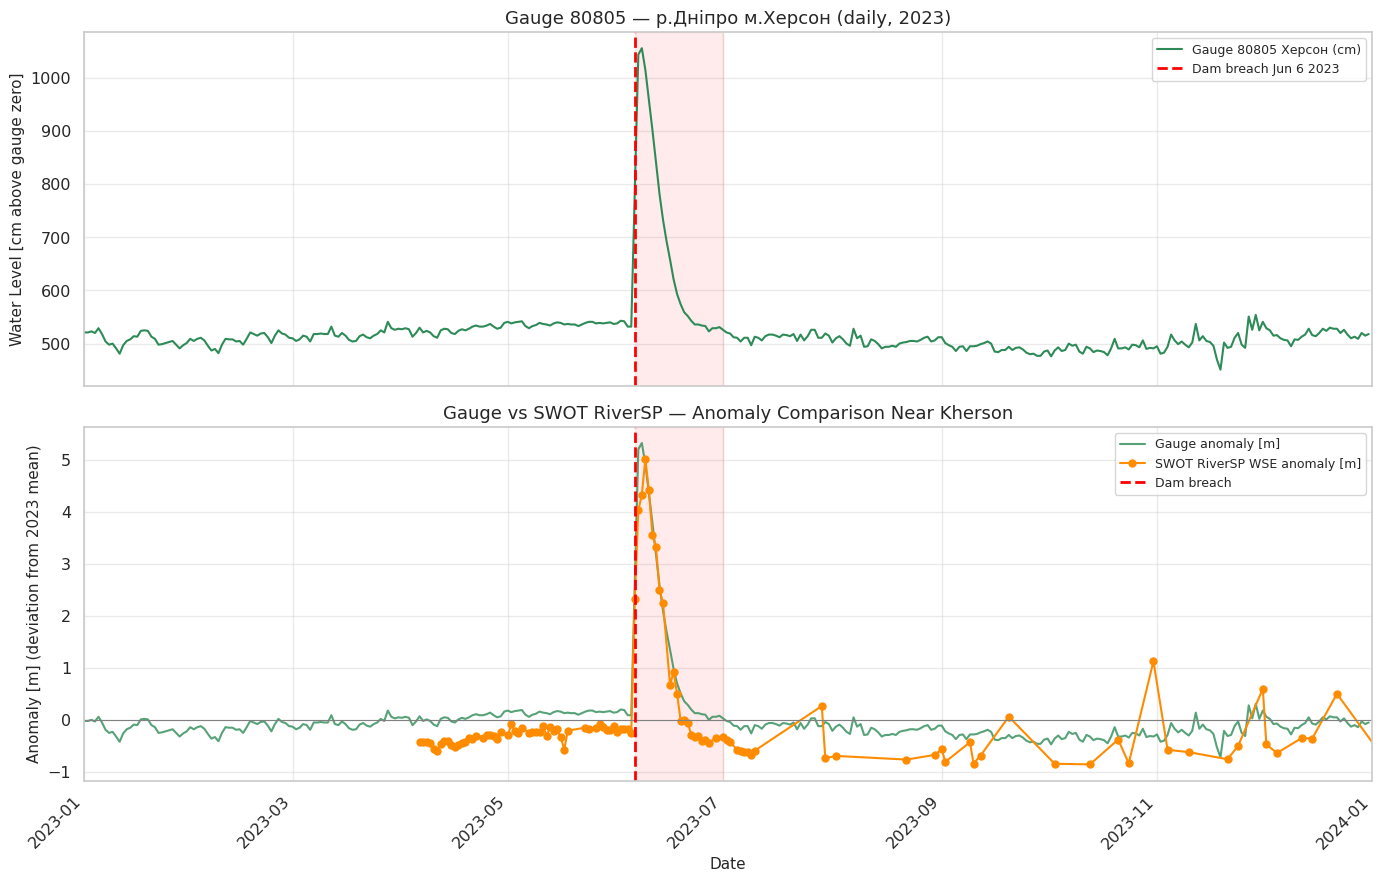

Saved: /mnt/c/Users/victo/PycharmProjects/SWOT-DNIPRO/data/figures/11_gauge_vs_swot.png

Correlation (gauge vs SWOT anomaly) on 256 paired obs: r=0.882  p=0.000


In [22]:
if df_gauge.empty:
    print("[SKIP] No gauge data to plot.")
elif df_river.empty:
    print("[SKIP] No RiverSP data for comparison.")
else:
    # Filter RiverSP near Kherson (within ~0.5° of gauge lat/lon)
    lat0, lon0 = GAUGE_STATION['lat'], GAUGE_STATION['lon']
    mask_near = (
        (df_river['p_lat'] >= lat0 - 0.5) & (df_river['p_lat'] <= lat0 + 0.5) &
        (df_river['p_lon'] >= lon0 - 0.5) & (df_river['p_lon'] <= lon0 + 0.5)
    )
    df_near = df_river[mask_near].copy()
    print(f"RiverSP reaches near Kherson (±0.5°): {df_near['reach_id'].nunique()} reaches, "
          f"{len(df_near):,} obs")

    if df_near.empty:
        print("[INFO] No RiverSP reaches within 0.5° of Kherson gauge — expanding search to ±1°")
        mask_near = (
            (df_river['p_lat'] >= lat0 - 1.0) & (df_river['p_lat'] <= lat0 + 1.0) &
            (df_river['p_lon'] >= lon0 - 1.0) & (df_river['p_lon'] <= lon0 + 1.0)
        )
        df_near = df_river[mask_near].copy()
        print(f"RiverSP reaches near Kherson (±1°): {df_near['reach_id'].nunique()} reaches, "
              f"{len(df_near):,} obs")

    if not df_near.empty:
        swot_near_ts = df_near.groupby('date').agg(
            wse_mean=('wse', 'mean'),
            wse_std=('wse', 'std'),
            n_obs=('wse', 'count'),
        ).reset_index()
        swot_near_ts['date'] = pd.to_datetime(swot_near_ts['date'])

        # Anomaly-based comparison: subtract 2023 mean to remove datum offset
        gauge_2023 = df_gauge.copy()
        gauge_2023['level_anom'] = gauge_2023['level_cm'] - gauge_2023['level_cm'].mean()

        swot_overlap = swot_near_ts[
            (swot_near_ts['date'] >= gauge_2023['date'].min()) &
            (swot_near_ts['date'] <= gauge_2023['date'].max())
        ]
        swot_wse_mean = swot_overlap['wse_mean'].mean() if not swot_overlap.empty else 0
        swot_near_ts['wse_anom'] = swot_near_ts['wse_mean'] - swot_wse_mean

        fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

        # Gauge absolute water level
        ax = axes[0]
        ax.plot(gauge_2023['date'], gauge_2023['level_cm'],
                color='seagreen', lw=1.5, label='Gauge 80805 Херсон (cm)')
        ax.axvline(DAM_BREACH, color='red', lw=2, linestyle='--', label='Dam breach Jun 6 2023')
        ax.axvspan(DAM_BREACH, BREACH_END, alpha=0.08, color='red')
        ax.set_ylabel('Water Level [cm above gauge zero]', fontsize=11)
        ax.set_title(f'Gauge 80805 — р.Дніпро м.Херсон (daily, 2023)', fontsize=13)
        ax.legend(fontsize=9); ax.grid(True, alpha=0.4)

        # Anomaly comparison
        ax2 = axes[1]
        ax2.plot(gauge_2023['date'], gauge_2023['level_anom'] / 100.0,
                 color='seagreen', lw=1.5, alpha=0.8, label='Gauge anomaly [m]')
        ax2.plot(swot_near_ts['date'], swot_near_ts['wse_anom'],
                 'o-', color='darkorange', ms=5, lw=1.5, label='SWOT RiverSP WSE anomaly [m]')
        ax2.axhline(0, color='gray', lw=0.8)
        ax2.axvline(DAM_BREACH, color='red', lw=2, linestyle='--', label='Dam breach')
        ax2.axvspan(DAM_BREACH, BREACH_END, alpha=0.08, color='red')
        ax2.set_ylabel('Anomaly [m] (deviation from 2023 mean)', fontsize=11)
        ax2.set_xlabel('Date', fontsize=11)
        ax2.set_title('Gauge vs SWOT RiverSP — Anomaly Comparison Near Kherson', fontsize=13)
        ax2.legend(fontsize=9); ax2.grid(True, alpha=0.4)

        for ax in axes:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
            ax.set_xlim(pd.Timestamp('2023-01-01'), pd.Timestamp('2024-01-01'))

        plt.tight_layout()
        plt.savefig(FIG_DIR / '11_gauge_vs_swot.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: {FIG_DIR / '11_gauge_vs_swot.png'}")

        # Correlation on overlapping dates
        merged = pd.merge_asof(
            gauge_2023.sort_values('date')[['date','level_anom']].rename(
                columns={'level_anom':'gauge_anom_cm'}),
            swot_near_ts.sort_values('date')[['date','wse_anom']],
            on='date', direction='nearest', tolerance=pd.Timedelta('5 days')
        ).dropna()
        if len(merged) >= 3:
            r, p = stats.pearsonr(merged['gauge_anom_cm'], merged['wse_anom'])
            print(f"\nCorrelation (gauge vs SWOT anomaly) on {len(merged)} paired obs: "
                  f"r={r:.3f}  p={p:.3f}")

## 14. LakeSP vs RiverSP Combined View

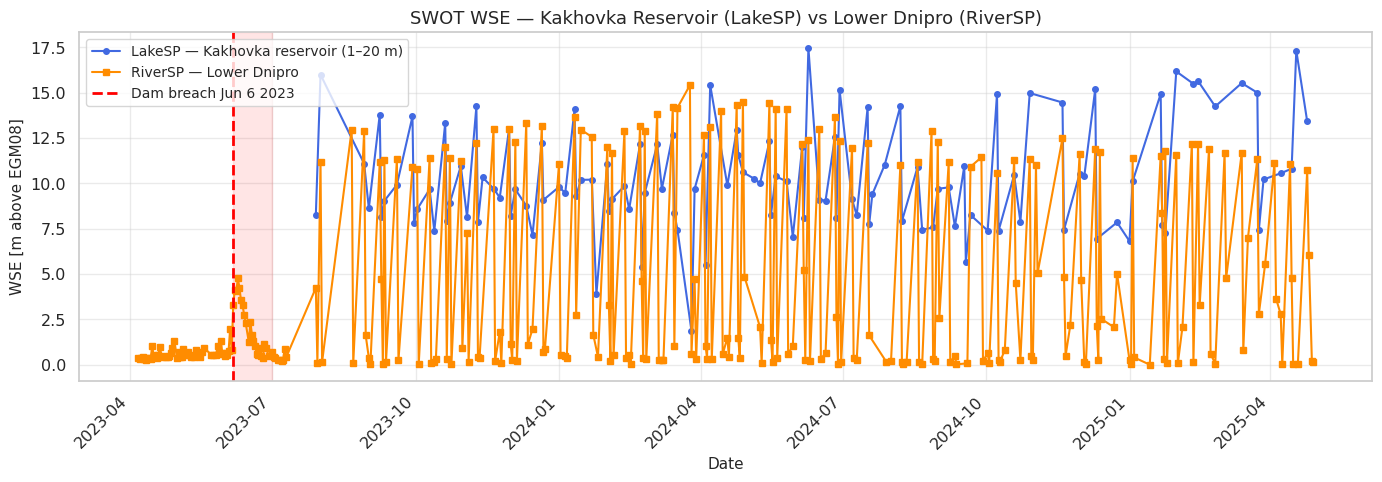

Saved: /mnt/c/Users/victo/PycharmProjects/SWOT-DNIPRO/data/figures/06_combined_wse.png


In [23]:
have_lake  = not swot_kakh_ts.empty or not swot_lake_ts.empty
have_river = not swot_river_ts.empty

lake_ts = swot_kakh_ts if not swot_kakh_ts.empty else swot_lake_ts

if not have_lake and not have_river:
    print("[SKIP] No data from either product.")
else:
    fig, ax = plt.subplots(figsize=(14, 5))

    if have_lake:
        label_l = 'LakeSP — Kakhovka reservoir (1–20 m)' if not swot_kakh_ts.empty                   else 'LakeSP — Kakhovka AOI (all water bodies)'
        ax.plot(lake_ts['date'], lake_ts['wse_area_wt'],
                'o-', color='royalblue', ms=4, lw=1.5, label=label_l)
    if have_river:
        ax.plot(swot_river_ts['date'], swot_river_ts['wse_mean'],
                's-', color='darkorange', ms=4, lw=1.5, label='RiverSP — Lower Dnipro')

    ax.axvline(DAM_BREACH, color='red', lw=2, linestyle='--', label='Dam breach Jun 6 2023')
    ax.axvspan(DAM_BREACH, BREACH_END, alpha=0.1, color='red')
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('WSE [m above EGM08]', fontsize=11)
    ax.set_title('SWOT WSE — Kakhovka Reservoir (LakeSP) vs Lower Dnipro (RiverSP)', fontsize=13)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '06_combined_wse.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {FIG_DIR / '06_combined_wse.png'}")

## 15. RiverSP Spatial Map — River Reaches

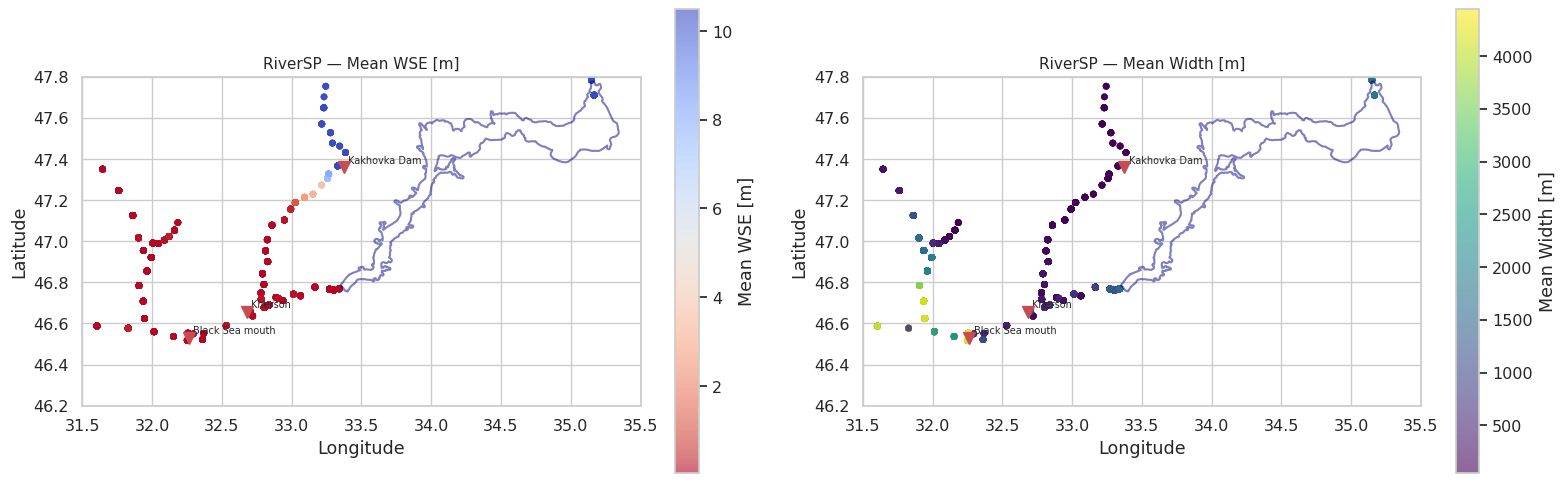

Saved: /mnt/c/Users/victo/PycharmProjects/SWOT-DNIPRO/data/figures/07_riversp_spatial.png


In [24]:
if df_river.empty or 'p_lat' not in df_river.columns:
    print("[SKIP] No RiverSP geometry/coordinates.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for ax, col, cmap, label in [
        (axes[0], 'wse',   'coolwarm_r', 'Mean WSE [m]'),
        (axes[1], 'width', 'viridis',    'Mean Width [m]'),
    ]:
        if col not in df_river.columns:
            ax.text(0.5, 0.5, f'{col} not available',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(label); continue

        recent = df_river.dropna(subset=[col, 'p_lat', 'p_lon'])
        sc = ax.scatter(recent['p_lon'], recent['p_lat'],
                        c=recent[col], cmap=cmap,
                        s=15, alpha=0.6,
                        vmin=recent[col].quantile(0.05),
                        vmax=recent[col].quantile(0.95))
        plt.colorbar(sc, ax=ax, label=label, shrink=0.7)

        gdf_sa.boundary.plot(ax=ax, color='navy', lw=1.5, alpha=0.5)

        for name, (lat, lon) in COORDS.items():
            ax.plot(lon, lat, 'rv', ms=8, zorder=5)
            ax.annotate(name, xy=(lon, lat), xytext=(3, 3),
                        textcoords='offset points', fontsize=7)

        ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
        ax.set_title(f'RiverSP — {label}', fontsize=11)
        minlon, minlat, maxlon, maxlat = RIVER_BBOX
        ax.set_xlim(minlon, maxlon); ax.set_ylim(minlat, maxlat)

    plt.tight_layout()
    plt.savefig(FIG_DIR / '07_riversp_spatial.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {FIG_DIR / '07_riversp_spatial.png'}")

## 16. Interactive Map (Folium)

In [25]:
if not HAS_FOLIUM:
    print("[SKIP] folium not installed. Run: pip install folium")
else:
    map_center = [(bounds[1]+bounds[3])/2, (bounds[0]+bounds[2])/2]
    m = folium.Map(location=map_center, zoom_start=8, tiles='CartoDB positron')

    GeoJson(
        json.loads(gdf_sa.to_json()),
        name='Kakhovka SA',
        style_function=lambda _: {'fillColor':'#3388ff','color':'#0033cc',
                                   'weight':2,'fillOpacity':0.1}
    ).add_to(m)

    for name, (lat, lon) in COORDS.items():
        Marker([lat, lon], popup=name, tooltip=name,
               icon=folium.Icon(color='red', icon='info-sign')).add_to(m)

    # Gauge station
    Marker(
        [GAUGE_STATION['lat'], GAUGE_STATION['lon']],
        popup=GAUGE_STATION['name'],
        tooltip=GAUGE_STATION['name'],
        icon=folium.Icon(color='green', icon='tint'),
    ).add_to(m)

    # LakeSP: reservoir observations (df_kakh if available)
    src = df_kakh if not df_kakh.empty else df_lake
    if not src.empty and 'geometry' in src.columns:
        gdf_pts = gpd.GeoDataFrame(src.dropna(subset=['wse']),
                                    geometry='geometry', crs='EPSG:4326')
        sample = gdf_pts.sample(min(300, len(gdf_pts)), random_state=42)
        wse_lo, wse_hi = sample['wse'].quantile(0.05), sample['wse'].quantile(0.95)
        cmap_f = plt.cm.RdYlBu_r

        lake_layer = folium.FeatureGroup(name='LakeSP observations')
        for _, row in sample.iterrows():
            try:
                t = float(np.clip((row['wse']-wse_lo)/max(wse_hi-wse_lo, 1e-6), 0, 1))
                r_c, g_c, b_c, _ = cmap_f(t)
                col = f'#{int(r_c*255):02x}{int(g_c*255):02x}{int(b_c*255):02x}'
                cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
                CircleMarker([cy, cx], radius=5, color=col, fill=True, fill_opacity=0.8,
                             popup=f"WSE={row['wse']:.2f} m | lake_id={row.get('lake_id','?')}",
                             ).add_to(lake_layer)
            except Exception:
                pass
        lake_layer.add_to(m)

    # RiverSP width anomaly layer (post-breach)
    if not df_width_anomaly.empty and 'p_lat' in df_width_anomaly.columns:
        post_layer = folium.FeatureGroup(name='RiverSP post-breach width anomaly')
        post_anom_all = df_width_anomaly[df_width_anomaly['date'] >= BREACH_END]
        reach_anom = post_anom_all.groupby('reach_id').agg(
            anom=('width_anomaly_pct', 'mean'),
            p_lat=('p_lat', 'mean'),
            p_lon=('p_lon', 'mean'),
        ).reset_index()
        vmax_a = reach_anom['anom'].abs().quantile(0.95)
        for _, row in reach_anom.iterrows():
            try:
                t = float(np.clip((row['anom'] + vmax_a) / max(2*vmax_a, 1e-6), 0, 1))
                r_c, g_c, b_c, _ = plt.cm.RdBu_r(t)
                col = f'#{int(r_c*255):02x}{int(g_c*255):02x}{int(b_c*255):02x}'
                CircleMarker(
                    [row['p_lat'], row['p_lon']], radius=6,
                    color=col, fill=True, fill_opacity=0.8,
                    popup=f"reach {row['reach_id']}: Δwidth={row['anom']:.1f}%",
                ).add_to(post_layer)
            except Exception:
                pass
        post_layer.add_to(m)

    LayerControl().add_to(m)
    display(m)

## 17. Summary

In [26]:
print("=" * 60)
print("SWOT ANALYSIS SUMMARY")
print("=" * 60)

print(f"\nFiles on disk:")
print(f"  LakeSP  shapefiles : {len(lakesp_shps):,}")
print(f"  RiverSP shapefiles : {len(riversp_shps):,}")

if not df_lake.empty:
    print(f"\nLakeSP in Kakhovka AOI (all water bodies):")
    print(f"  Observations : {len(df_lake):,}")
    print(f"  Dates        : {df_lake['date'].min().date()} → {df_lake['date'].max().date()}")
    print(f"  WSE range    : {df_lake['wse'].min():.2f} – {df_lake['wse'].max():.2f} m")

if not df_kakh.empty:
    print(f"\nKakhovka Reservoir (WSE 1–20 m filter):")
    print(f"  Observations : {len(df_kakh):,}")
    pre  = swot_kakh_ts[swot_kakh_ts['date'] < DAM_BREACH]
    post = swot_kakh_ts[swot_kakh_ts['date'] >= BREACH_END]
    if not pre.empty:
        print(f"  Pre-breach mean WSE  : {pre['wse_area_wt'].mean():.3f} m")
    if not post.empty:
        print(f"  Post-breach mean WSE : {post['wse_area_wt'].mean():.3f} m")
    if not pre.empty and not post.empty:
        print(f"  WSE drop (dam breach): {pre['wse_area_wt'].mean() - post['wse_area_wt'].mean():.3f} m")

if not df_river.empty:
    print(f"\nRiverSP in Dnipro region:")
    print(f"  Observations : {len(df_river):,}")
    print(f"  Dates        : {df_river['date'].min().date()} → {df_river['date'].max().date()}")
    print(f"  Unique reaches: {df_river['reach_id'].nunique():,}")

if not df_width_anomaly.empty:
    post_anom_df = df_width_anomaly[df_width_anomaly['date'] >= BREACH_END]
    if not post_anom_df.empty:
        print(f"\nRiverSP flooding analysis:")
        print(f"  Post-breach mean width anomaly: "
              f"{post_anom_df['width_anomaly'].mean():.1f} m "
              f"({post_anom_df['width_anomaly_pct'].mean():.1f}%)")
        flood_reaches = (post_anom_df.groupby('reach_id')['width_anomaly_pct'].mean() > 20).sum()
        print(f"  Reaches with >20% width increase: {flood_reaches}")

if not df_gauge.empty:
    print(f"\nGauge data (80805 Херсон, 2023):")
    print(f"  Daily observations: {len(df_gauge)}")
    june_gauge = df_gauge[df_gauge['date'].dt.month == 6]
    print(f"  June 2023 mean level: {june_gauge['level_cm'].mean():.0f} cm")

print(f"\nFigures saved to: {FIG_DIR}")
print("=" * 60)

SWOT ANALYSIS SUMMARY

Files on disk:
  LakeSP  shapefiles : 1,685
  RiverSP shapefiles : 1,891

LakeSP in Kakhovka AOI (all water bodies):
  Observations : 2,192
  Dates        : 2023-07-29 → 2025-04-25
  WSE range    : 0.09 – 49.99 m

Kakhovka Reservoir (WSE 1–20 m filter):
  Observations : 1,401
  Post-breach mean WSE : 10.293 m

RiverSP in Dnipro region:
  Observations : 5,055
  Dates        : 2023-04-06 → 2025-04-29
  Unique reaches: 67

RiverSP flooding analysis:
  Post-breach mean width anomaly: -64.8 m (-4.2%)
  Reaches with >20% width increase: 5

Gauge data (80805 Херсон, 2023):
  Daily observations: 365
  June 2023 mean level: 662 cm

Figures saved to: /mnt/c/Users/victo/PycharmProjects/SWOT-DNIPRO/data/figures
